<h1> Entanglement based Quantum Key Distribution Network</h1>


In [1]:
from qiskit import QuantumRegister, ClassicalRegister,QuantumCircuit
import numpy as np
import random
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector,Operator
from qiskit.visualization import circuit_drawer, plot_histogram
import matplotlib.pyplot as plt
# from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager

from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
import re
from qiskit_ibm_runtime import EstimatorV2 as Estimator

In [2]:
# Comment the next two command lines if no acces to real quantum hardware is granted
service = QiskitRuntimeService(channel ="ibm_cloud", token= 'Your API here',
                              instance="Your Instance here")
  
backend = service.least_busy(simulator=False, operational=True)


# backend = FakeFez()# uncomment this command line if needed to run with fake backend
# backend = AerSimulator()# uncomment this command line if needed to run with free noise
pm = generate_preset_pass_manager(optimization_level = 2,
                             backend = backend,
                             seed_transpiler = 24578)
sampler = SamplerV2(mode=backend)

In [3]:
backend

ibm-boston


In [4]:
#|Psi> = (|000>+|111>)/sqrt(2)
nq = 6
N = 2000
basis_1 = ['X','V','Y','R']
basis_k = ['X','Y']
basis_choices = [[random.choice(basis_1) for _ in range(N)]]+[[random.choice(basis_k) 
                                                               for _ in range(N)] for _ in range(nq-1) ]
basis_choices
QR = QuantumRegister(nq)
CR = ClassicalRegister(nq)
QR_e = QuantumRegister(nq)
CR_e = ClassicalRegister(nq)

In [5]:
basis_choices

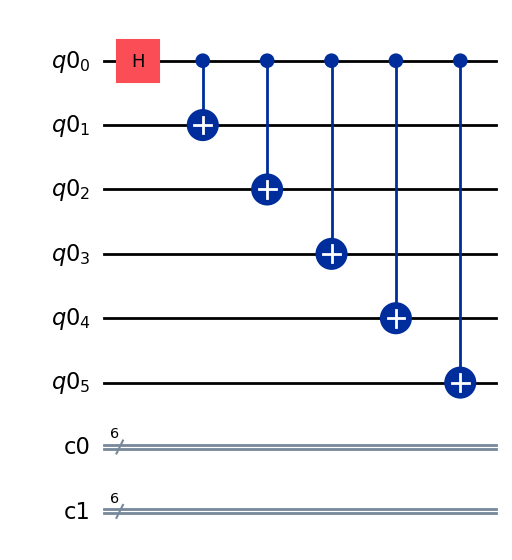

In [6]:
def N_particles_state(nq,QR,CR,CR_e):
    qc = QuantumCircuit(QR, CR, CR_e )
    qc.h(QR[0])
    for k in range(1,nq):
        qc.cx(QR[0],QR[k])
    return qc

Psi = N_particles_state(nq,QR,CR,CR_e)
Psi.draw('mpl')



<h3> d) Measurement bases encoded with quantum gates </h3>


Observables in the xy-plane: $O(\theta) = cos(\theta) \sigma_x + sin(\theta) \sigma_y$


Specific angles giving the maximal Svetlichny violation
\begin{equation}
\begin{aligned}
&A:\quad \theta_A = {\frac{3\pi}{4},0,\frac{\pi}{4},\frac{\pi}{2}} \quad\Rightarrow\quad A = V={\frac{\sigma_x-\sigma_y}{\sqrt{2}},R=\frac{\sigma_x+\sigma_y}{\sqrt{2}},X,Y }\\[6pt]
&B:\quad \theta_B = {0, \frac{\pi}{2}} \quad\Rightarrow\quad B = {\sigma_x,\sigma_y}\\[6pt]
&B:\quad \theta_C = {0, \frac{\pi}{2}} \quad\Rightarrow\quad C = {\sigma_x,\sigma_y}
\end{aligned}
\end{equation}





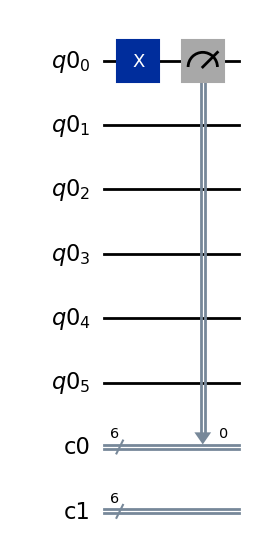

In [7]:

def legitimate_users_mes_circs(nq,N,QR,CR,CR_e):
    #  Legitimate_parties_1's qubit onto the X basis
    Legitimate_parties_1_X = QuantumCircuit(QR,CR,CR_e)
    Legitimate_parties_1_X.x(QR[0])
    Legitimate_parties_1_X.measure(QR[0],CR[0])
    
    # Legitimate_parties_1's qubit onto the Y basis 
    Legitimate_parties_1_Y = QuantumCircuit(QR,CR,CR_e)
    # Legitimate_parties_1_Y.sdg(QR_abc[0])
    Legitimate_parties_1_Y.y(QR[0])
    Legitimate_parties_1_Y.measure(QR[0],CR[0])
    
    # Legitimate_parties_1's qubit onto the R basis R = Rz(-pi/4)H = (X+Y)/sqrt(2)
    Legitimate_parties_1_R = QuantumCircuit(QR,CR,CR_e)
    Legitimate_parties_1_R.rz(-np.pi/4,QR[0])
    Legitimate_parties_1_R.h(QR[0])
    Legitimate_parties_1_R.measure(QR[0],CR[0])

    # Legitimate_parties_1's qubit onto the V basis V = Rz(pi/4)H = (X-Y)/sqrt(2)
    Legitimate_parties_1_V = QuantumCircuit(QR,CR,CR_e)
    Legitimate_parties_1_V.rz(np.pi/4,QR[0])
    Legitimate_parties_1_V.h(QR[0])
    Legitimate_parties_1_V.measure(QR[0],CR[0])
    Legitimate_parties_1_meas_circs = [Legitimate_parties_1_X, Legitimate_parties_1_Y, 
                                       Legitimate_parties_1_V, Legitimate_parties_1_R]
    
    Legitimate_parties_k_meas_circs = []
    Legitimate_parties_k_meas_circs2 = []
    for k in range(1,nq):
        # Legitimate_parties_k_basis = {'X','Y'}
        # Legitimate_parties_k's qubit onto the Y basis
        
        Legitimate_parties_k_Y = QuantumCircuit(QR,CR,CR_e)
        Legitimate_parties_k_Y.sdg(QR[k])
        Legitimate_parties_k_Y.h(QR[k])
        Legitimate_parties_k_Y.measure(QR[k],CR[k])
        
        Legitimate_parties_k_Y2 = QuantumCircuit(QR,CR,CR_e)
        Legitimate_parties_k_Y2.y(QR[k])
        Legitimate_parties_k_Y2.measure(QR[k],CR[k])
    
        # Legitimate_parties_k's qubit onto the X basis
        Legitimate_parties_k_X = QuantumCircuit(QR,CR,CR_e)
        Legitimate_parties_k_X.h(QR[k])
        Legitimate_parties_k_X.measure(QR[k],CR[k])
        
        Legitimate_parties_k_X2 = QuantumCircuit(QR,CR,CR_e)
        Legitimate_parties_k_X2.x(QR[k])
        Legitimate_parties_k_X2.measure(QR[k],CR[k])
        
        Legitimate_parties_k_meas_circs.append([Legitimate_parties_k_X,Legitimate_parties_k_Y])
        Legitimate_parties_k_meas_circs2.append([Legitimate_parties_k_X2,Legitimate_parties_k_Y2])
    
    Legitimate_parties_meas_circs = [Legitimate_parties_1_meas_circs]+Legitimate_parties_k_meas_circs
    Legitimate_parties_meas_circs2 = [Legitimate_parties_1_meas_circs]+Legitimate_parties_k_meas_circs2
    return Legitimate_parties_meas_circs,Legitimate_parties_meas_circs2
    
Legitimate_parties_meas_circs,Legitimate_parties_meas_circs2 = legitimate_users_mes_circs(nq,N,QR,CR,CR_e)

Legitimate_parties_meas_circs2[0][0].draw('mpl')

In [8]:
def circs(nq,N,basis_choices,Psi,Legitimate_parties_meas_circs,
          Legitimate_parties_meas_circs2):
    circuits = [] 
    circuits2 = [] 
    #basis_choices[[],[]...[]]
    
    for k in range(N):
        if basis_choices[0][k] == 'X':
            circ = Psi.compose(Legitimate_parties_meas_circs[0][0])
            circ2 = Psi.compose(Legitimate_parties_meas_circs2[0][0])
            circuits.append(circ)
            circuits2.append(circ2)
        elif basis_choices[0][k] == 'Y':
            circ = Psi.compose(Legitimate_parties_meas_circs[0][1])
            circ2 = Psi.compose(Legitimate_parties_meas_circs2[0][1])
            circuits.append(circ)
            circuits2.append(circ2)
        elif basis_choices[0][k] == 'V':
            circ = Psi.compose(Legitimate_parties_meas_circs[0][2])
            circ2 = Psi.compose(Legitimate_parties_meas_circs2[0][2])
            circuits.append(circ)
            circuits2.append(circ2)
    
        elif basis_choices[0][k] == 'R':
            circ = Psi.compose(Legitimate_parties_meas_circs[0][3])
            circ2 = Psi.compose(Legitimate_parties_meas_circs2[0][3])
            circuits.append(circ)
            circuits2.append(circ2)
    
    for j in range(1,nq):
        for k in range(N):  
            circs = circuits[k]
            circs2 = circuits2[k]
            if basis_choices[j][k] == 'X':
                circ = circs.compose(Legitimate_parties_meas_circs[j][0])
                circ2 = circs2.compose(Legitimate_parties_meas_circs2[j][0])
                circuits[k] = circ
                circuits2[k] = circ2
            elif basis_choices[j][k] == 'Y':
                circ = circs.compose(Legitimate_parties_meas_circs[j][1])
                circ2 = circs2.compose(Legitimate_parties_meas_circs2[j][1])
                circuits[k] = circ
                circuits2[k] = circ2
    return circuits,circuits2

circuits, circuits2 = circs(nq,N,basis_choices,Psi,Legitimate_parties_meas_circs,
                 Legitimate_parties_meas_circs2)
    

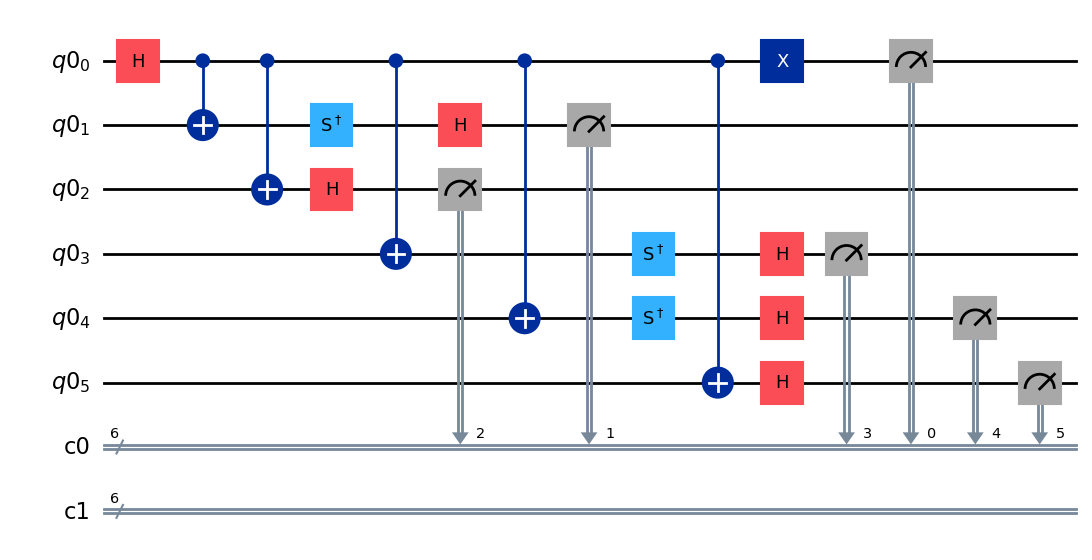

In [9]:
circuits[-1].draw('mpl')

In [10]:
print(len(circuits))
print(len(circuits2))

2000
2000


In [11]:
def simulation(N,backend,circuits,circuits2):
    Result = []
    Result2 = []
    for k in range(N):
        qc = circuits[k]
        qc2 = circuits2[k]
        qct = pm.run(qc)
        qct2 = pm.run(qc2)
        results = sampler.run([qct], shots = 1).result() 
        res = results[0].join_data().get_counts()

        results2 = sampler.run([qct2], shots = 1).result() 
        res2 = results2[0].join_data().get_counts()
        
        Result.append(res)
        Result2.append(res2)
    return Result,Result2
Result,Result2 = simulation(N,backend,circuits,circuits2)

[{'000000101110': 1}, {'000000101111': 1}, {'000000111000': 1}, {'000000101101': 1}, {'000000000010': 1}, {'000000000100': 1}, {'000000010010': 1}, {'000000000011': 1}, {'000000001101': 1}, {'000000011111': 1}, {'000000000001': 1}, {'000000100101': 1}, {'000000011011': 1}, {'000000010011': 1}, {'000000011100': 1}, {'000000000001': 1}, {'000000010100': 1}, {'000000010111': 1}, {'000000011011': 1}, {'000000011110': 1}, {'000000010001': 1}, {'000000010000': 1}, {'000000011001': 1}, {'000000010111': 1}, {'000000101110': 1}, {'000000000000': 1}, {'000000111010': 1}, {'000000010011': 1}, {'000000111110': 1}, {'000000100100': 1}, {'000000001000': 1}, {'000000010010': 1}, {'000000100011': 1}, {'000000000100': 1}, {'000000100100': 1}, {'000000000011': 1}, {'000000000100': 1}, {'000000010111': 1}, {'000000001110': 1}, {'000000000001': 1}, {'000000000101': 1}, {'000000110010': 1}, {'000000111010': 1}, {'000000110110': 1}, {'000000110101': 1}, {'000000110101': 1}, {'000000010101': 1}, {'0000001101

In [ ]:
Result = [{'000000101110': 1}, {'000000101111': 1}, {'000000111000': 1}, {'000000101101': 1}, {'000000000010': 1}, {'000000000100': 1}, {'000000010010': 1}, {'000000000011': 1}, {'000000001101': 1}, {'000000011111': 1}, {'000000000001': 1}, {'000000100101': 1}, {'000000011011': 1}, {'000000010011': 1}, {'000000011100': 1}, {'000000000001': 1}, {'000000010100': 1}, {'000000010111': 1}, {'000000011011': 1}, {'000000011110': 1}, {'000000010001': 1}, {'000000010000': 1}, {'000000011001': 1}, {'000000010111': 1}, {'000000101110': 1}, {'000000000000': 1}, {'000000111010': 1}, {'000000010011': 1}, {'000000111110': 1}, {'000000100100': 1}, {'000000001000': 1}, {'000000010010': 1}, {'000000100011': 1}, {'000000000100': 1}, {'000000100100': 1}, {'000000000011': 1}, {'000000000100': 1}, {'000000010111': 1}, {'000000001110': 1}, {'000000000001': 1}, {'000000000101': 1}, {'000000110010': 1}, {'000000111010': 1}, {'000000110110': 1}, {'000000110101': 1}, {'000000110101': 1}, {'000000010101': 1}, {'000000110110': 1}, {'000000011110': 1}, {'000000110001': 1}, {'000000000110': 1}, {'000000110110': 1}, {'000000000010': 1}, {'000000111111': 1}, {'000000101101': 1}, {'000000101010': 1}, {'000000110000': 1}, {'000000001000': 1}, {'000000111110': 1}, {'000000100110': 1}, {'000000001011': 1}, {'000000110100': 1}, {'000000001110': 1}, {'000000111000': 1}, {'000000001100': 1}, {'000000110010': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000101001': 1}, {'000000101110': 1}, {'000000110010': 1}, {'000000000100': 1}, {'000000101001': 1}, {'000000101011': 1}, {'000000001010': 1}, {'000000111010': 1}, {'000000001010': 1}, {'000000011101': 1}, {'000000110100': 1}, {'000000001111': 1}, {'000000101010': 1}, {'000000010111': 1}, {'000000110001': 1}, {'000000110011': 1}, {'000000111001': 1}, {'000000100011': 1}, {'000000011111': 1}, {'000000101100': 1}, {'000000101111': 1}, {'000000111101': 1}, {'000000111001': 1}, {'000000011100': 1}, {'000000100011': 1}, {'000000101011': 1}, {'000000110000': 1}, {'000000010101': 1}, {'000000110100': 1}, {'000000110000': 1}, {'000000100000': 1}, {'000000000100': 1}, {'000000010100': 1}, {'000000000110': 1}, {'000000110100': 1}, {'000000001110': 1}, {'000000001111': 1}, {'000000111111': 1}, {'000000001101': 1}, {'000000011111': 1}, {'000000001010': 1}, {'000000101010': 1}, {'000000011001': 1}, {'000000010001': 1}, {'000000010101': 1}, {'000000011000': 1}, {'000000001110': 1}, {'000000010111': 1}, {'000000000010': 1}, {'000000010011': 1}, {'000000111101': 1}, {'000000100111': 1}, {'000000011000': 1}, {'000000000001': 1}, {'000000101100': 1}, {'000000011100': 1}, {'000000000000': 1}, {'000000100110': 1}, {'000000111000': 1}, {'000000010001': 1}, {'000000001101': 1}, {'000000100100': 1}, {'000000111101': 1}, {'000000000101': 1}, {'000000001010': 1}, {'000000100100': 1}, {'000000001100': 1}, {'000000110010': 1}, {'000000111111': 1}, {'000000001011': 1}, {'000000010000': 1}, {'000000000100': 1}, {'000000101110': 1}, {'000000000101': 1}, {'000000110000': 1}, {'000000011110': 1}, {'000000001001': 1}, {'000000010011': 1}, {'000000000010': 1}, {'000000000000': 1}, {'000000111011': 1}, {'000000001001': 1}, {'000000010000': 1}, {'000000110101': 1}, {'000000011001': 1}, {'000000010011': 1}, {'000000000110': 1}, {'000000111001': 1}, {'000000101010': 1}, {'000000101010': 1}, {'000000111010': 1}, {'000000010000': 1}, {'000000000010': 1}, {'000000110000': 1}, {'000000110000': 1}, {'000000010110': 1}, {'000000000010': 1}, {'000000000001': 1}, {'000000001000': 1}, {'000000001000': 1}, {'000000000101': 1}, {'000000111100': 1}, {'000000010001': 1}, {'000000101110': 1}, {'000000000001': 1}, {'000000010010': 1}, {'000000111011': 1}, {'000000000001': 1}, {'000000001101': 1}, {'000000011101': 1}, {'000000101001': 1}, {'000000110010': 1}, {'000000011000': 1}, {'000000011001': 1}, {'000000000101': 1}, {'000000101011': 1}, {'000000010010': 1}, {'000000001111': 1}, {'000000111011': 1}, {'000000001001': 1}, {'000000100101': 1}, {'000000111010': 1}, {'000000010110': 1}, {'000000110001': 1}, {'000000000100': 1}, {'000000000110': 1}, {'000000001010': 1}, {'000000001111': 1}, {'000000101100': 1}, {'000000100101': 1}, {'000000111010': 1}, {'000000010010': 1}, {'000000100101': 1}, {'000000111100': 1}, {'000000000110': 1}, {'000000010000': 1}, {'000000011100': 1}, {'000000100000': 1}, {'000000111011': 1}, {'000000000111': 1}, {'000000001011': 1}, {'000000000110': 1}, {'000000101010': 1}, {'000000111010': 1}, {'000000101111': 1}, {'000000111111': 1}, {'000000010010': 1}, {'000000111011': 1}, {'000000111101': 1}, {'000000111011': 1}, {'000000101010': 1}, {'000000011000': 1}, {'000000100001': 1}, {'000000010101': 1}, {'000000010011': 1}, {'000000011011': 1}, {'000000110001': 1}, {'000000110101': 1}, {'000000001111': 1}, {'000000000010': 1}, {'000000000001': 1}, {'000000010011': 1}, {'000000001000': 1}, {'000000011001': 1}, {'000000010101': 1}, {'000000100000': 1}, {'000000101001': 1}, {'000000111110': 1}, {'000000001000': 1}, {'000000010010': 1}, {'000000011110': 1}, {'000000000100': 1}, {'000000010101': 1}, {'000000011010': 1}, {'000000011100': 1}, {'000000111000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000001010': 1}, {'000000001110': 1}, {'000000110010': 1}, {'000000110110': 1}, {'000000000011': 1}, {'000000110001': 1}, {'000000111001': 1}, {'000000001010': 1}, {'000000111101': 1}, {'000000101001': 1}, {'000000110100': 1}, {'000000000011': 1}, {'000000111001': 1}, {'000000110001': 1}, {'000000111001': 1}, {'000000010110': 1}, {'000000101011': 1}, {'000000000110': 1}, {'000000110101': 1}, {'000000100011': 1}, {'000000001010': 1}, {'000000100110': 1}, {'000000010100': 1}, {'000000010110': 1}, {'000000100000': 1}, {'000000011011': 1}, {'000000100110': 1}, {'000000001101': 1}, {'000000110001': 1}, {'000000110011': 1}, {'000000111010': 1}, {'000000101001': 1}, {'000000001111': 1}, {'000000000001': 1}, {'000000011110': 1}, {'000000010101': 1}, {'000000001010': 1}, {'000000010000': 1}, {'000000100110': 1}, {'000000101110': 1}, {'000000011010': 1}, {'000000000111': 1}, {'000000101101': 1}, {'000000111101': 1}, {'000000011000': 1}, {'000000011110': 1}, {'000000101000': 1}, {'000000111101': 1}, {'000000001001': 1}, {'000000010100': 1}, {'000000110101': 1}, {'000000001100': 1}, {'000000111111': 1}, {'000000000010': 1}, {'000000011101': 1}, {'000000011000': 1}, {'000000000010': 1}, {'000000010100': 1}, {'000000100100': 1}, {'000000100010': 1}, {'000000111111': 1}, {'000000111001': 1}, {'000000010101': 1}, {'000000000101': 1}, {'000000010101': 1}, {'000000100101': 1}, {'000000110101': 1}, {'000000101101': 1}, {'000000011101': 1}, {'000000010001': 1}, {'000000111000': 1}, {'000000011111': 1}, {'000000001111': 1}, {'000000001010': 1}, {'000000111010': 1}, {'000000111101': 1}, {'000000010110': 1}, {'000000001011': 1}, {'000000100010': 1}, {'000000011000': 1}, {'000000101110': 1}, {'000000011100': 1}, {'000000011111': 1}, {'000000001111': 1}, {'000000001100': 1}, {'000000001111': 1}, {'000000010010': 1}, {'000000000011': 1}, {'000000101000': 1}, {'000000001000': 1}, {'000000111001': 1}, {'000000010100': 1}, {'000000111010': 1}, {'000000100100': 1}, {'000000111101': 1}, {'000000001001': 1}, {'000000011101': 1}, {'000000010101': 1}, {'000000101010': 1}, {'000000101100': 1}, {'000000010001': 1}, {'000000001100': 1}, {'000000111010': 1}, {'000000011110': 1}, {'000000110001': 1}, {'000000100111': 1}, {'000000011110': 1}, {'000000000011': 1}, {'000000100100': 1}, {'000000101011': 1}, {'000000011001': 1}, {'000000011010': 1}, {'000000011100': 1}, {'000000010001': 1}, {'000000101010': 1}, {'000000011010': 1}, {'000000100101': 1}, {'000000001011': 1}, {'000000000011': 1}, {'000000010111': 1}, {'000000010101': 1}, {'000000111011': 1}, {'000000110010': 1}, {'000000110010': 1}, {'000000011110': 1}, {'000000001100': 1}, {'000000010010': 1}, {'000000100001': 1}, {'000000101010': 1}, {'000000111110': 1}, {'000000010001': 1}, {'000000011001': 1}, {'000000010100': 1}, {'000000100110': 1}, {'000000110010': 1}, {'000000011011': 1}, {'000000100100': 1}, {'000000100010': 1}, {'000000011000': 1}, {'000000011111': 1}, {'000000101110': 1}, {'000000101111': 1}, {'000000011011': 1}, {'000000011101': 1}, {'000000000011': 1}, {'000000111001': 1}, {'000000100101': 1}, {'000000001111': 1}, {'000000010000': 1}, {'000000111001': 1}, {'000000111010': 1}, {'000000110011': 1}, {'000000110101': 1}, {'000000101111': 1}, {'000000010111': 1}, {'000000110111': 1}, {'000000110010': 1}, {'000000110011': 1}, {'000000100100': 1}, {'000000010010': 1}, {'000000000100': 1}, {'000000001111': 1}, {'000000101011': 1}, {'000000011100': 1}, {'000000110000': 1}, {'000000001000': 1}, {'000000110100': 1}, {'000000011010': 1}, {'000000110100': 1}, {'000000000100': 1}, {'000000100000': 1}, {'000000010111': 1}, {'000000000110': 1}, {'000000111110': 1}, {'000000101010': 1}, {'000000000011': 1}, {'000000001101': 1}, {'000000001100': 1}, {'000000101011': 1}, {'000000000100': 1}, {'000000110111': 1}, {'000000100100': 1}, {'000000001010': 1}, {'000000011001': 1}, {'000000001110': 1}, {'000000110110': 1}, {'000000111101': 1}, {'000000000101': 1}, {'000000001011': 1}, {'000000100111': 1}, {'000000111101': 1}, {'000000111011': 1}, {'000000100111': 1}, {'000000101111': 1}, {'000000110011': 1}, {'000000000111': 1}, {'000000000110': 1}, {'000000011010': 1}, {'000000101111': 1}, {'000000001111': 1}, {'000000000101': 1}, {'000000001010': 1}, {'000000110110': 1}, {'000000011011': 1}, {'000000100010': 1}, {'000000010101': 1}, {'000000100010': 1}, {'000000110100': 1}, {'000000110101': 1}, {'000000000110': 1}, {'000000111011': 1}, {'000000100001': 1}, {'000000100001': 1}, {'000000010001': 1}, {'000000100011': 1}, {'000000000101': 1}, {'000000111001': 1}, {'000000010111': 1}, {'000000101111': 1}, {'000000110011': 1}, {'000000001110': 1}, {'000000001010': 1}, {'000000000101': 1}, {'000000001010': 1}, {'000000011101': 1}, {'000000011101': 1}, {'000000011111': 1}, {'000000111111': 1}, {'000000110001': 1}, {'000000111110': 1}, {'000000101110': 1}, {'000000111011': 1}, {'000000100010': 1}, {'000000111100': 1}, {'000000100101': 1}, {'000000011000': 1}, {'000000111101': 1}, {'000000001100': 1}, {'000000100111': 1}, {'000000001011': 1}, {'000000001001': 1}, {'000000000111': 1}, {'000000101110': 1}, {'000000001111': 1}, {'000000010111': 1}, {'000000101000': 1}, {'000000011010': 1}, {'000000001101': 1}, {'000000011001': 1}, {'000000010010': 1}, {'000000110001': 1}, {'000000011111': 1}, {'000000000000': 1}, {'000000110101': 1}, {'000000101110': 1}, {'000000000011': 1}, {'000000011010': 1}, {'000000010001': 1}, {'000000110010': 1}, {'000000001101': 1}, {'000000101111': 1}, {'000000000111': 1}, {'000000010000': 1}, {'000000010110': 1}, {'000000011000': 1}, {'000000111101': 1}, {'000000011011': 1}, {'000000001101': 1}, {'000000111110': 1}, {'000000101001': 1}, {'000000111001': 1}, {'000000110010': 1}, {'000000000111': 1}, {'000000110111': 1}, {'000000100000': 1}, {'000000111110': 1}, {'000000011110': 1}, {'000000111110': 1}, {'000000101101': 1}, {'000000101010': 1}, {'000000100101': 1}, {'000000000000': 1}, {'000000011111': 1}, {'000000010001': 1}, {'000000011101': 1}, {'000000001011': 1}, {'000000011110': 1}, {'000000011011': 1}, {'000000001000': 1}, {'000000111001': 1}, {'000000110000': 1}, {'000000100110': 1}, {'000000110101': 1}, {'000000010011': 1}, {'000000000000': 1}, {'000000110101': 1}, {'000000000101': 1}, {'000000000010': 1}, {'000000100101': 1}, {'000000101010': 1}, {'000000111110': 1}, {'000000000010': 1}, {'000000001110': 1}, {'000000010010': 1}, {'000000001000': 1}, {'000000010001': 1}, {'000000100101': 1}, {'000000001110': 1}, {'000000100101': 1}, {'000000111010': 1}, {'000000100111': 1}, {'000000111001': 1}, {'000000111011': 1}, {'000000011011': 1}, {'000000010010': 1}, {'000000000010': 1}, {'000000001100': 1}, {'000000001111': 1}, {'000000111101': 1}, {'000000001010': 1}, {'000000000110': 1}, {'000000010111': 1}, {'000000100111': 1}, {'000000101111': 1}, {'000000011101': 1}, {'000000101110': 1}, {'000000010100': 1}, {'000000011010': 1}, {'000000110011': 1}, {'000000011100': 1}, {'000000100110': 1}, {'000000011101': 1}, {'000000111010': 1}, {'000000010010': 1}, {'000000100000': 1}, {'000000110011': 1}, {'000000010100': 1}, {'000000011011': 1}, {'000000000100': 1}, {'000000110110': 1}, {'000000101000': 1}, {'000000010001': 1}, {'000000001110': 1}, {'000000111011': 1}, {'000000010001': 1}, {'000000010000': 1}, {'000000100011': 1}, {'000000001101': 1}, {'000000001111': 1}, {'000000111011': 1}, {'000000001100': 1}, {'000000110100': 1}, {'000000100000': 1}, {'000000010011': 1}, {'000000001110': 1}, {'000000000110': 1}, {'000000111110': 1}, {'000000010000': 1}, {'000000101101': 1}, {'000000011010': 1}, {'000000000010': 1}, {'000000000011': 1}, {'000000000100': 1}, {'000000010110': 1}, {'000000100111': 1}, {'000000010100': 1}, {'000000010011': 1}, {'000000011010': 1}, {'000000000010': 1}, {'000000100100': 1}, {'000000110010': 1}, {'000000110101': 1}, {'000000000001': 1}, {'000000111001': 1}, {'000000010101': 1}, {'000000000110': 1}, {'000000110110': 1}, {'000000000011': 1}, {'000000011011': 1}, {'000000111010': 1}, {'000000000100': 1}, {'000000100101': 1}, {'000000100011': 1}, {'000000010100': 1}, {'000000111001': 1}, {'000000110001': 1}, {'000000000010': 1}, {'000000000001': 1}, {'000000000011': 1}, {'000000111011': 1}, {'000000010000': 1}, {'000000100101': 1}, {'000000101110': 1}, {'000000101110': 1}, {'000000101010': 1}, {'000000000100': 1}, {'000000110011': 1}, {'000000011000': 1}, {'000000101011': 1}, {'000000100100': 1}, {'000000011000': 1}, {'000000001011': 1}, {'000000100001': 1}, {'000000010010': 1}, {'000000110111': 1}, {'000000011100': 1}, {'000000011110': 1}, {'000000111001': 1}, {'000000101000': 1}, {'000000101100': 1}, {'000000000111': 1}, {'000000001100': 1}, {'000000010111': 1}, {'000000001000': 1}, {'000000110001': 1}, {'000000010110': 1}, {'000000000101': 1}, {'000000110101': 1}, {'000000111001': 1}, {'000000111010': 1}, {'000000011110': 1}, {'000000111010': 1}, {'000000100101': 1}, {'000000111010': 1}, {'000000001010': 1}, {'000000011100': 1}, {'000000010110': 1}, {'000000100100': 1}, {'000000001100': 1}, {'000000100010': 1}, {'000000010100': 1}, {'000000000000': 1}, {'000000001100': 1}, {'000000011001': 1}, {'000000110001': 1}, {'000000000100': 1}, {'000000010010': 1}, {'000000001010': 1}, {'000000101101': 1}, {'000000001010': 1}, {'000000100001': 1}, {'000000011000': 1}, {'000000010111': 1}, {'000000100101': 1}, {'000000011010': 1}, {'000000110010': 1}, {'000000011101': 1}, {'000000011001': 1}, {'000000100011': 1}, {'000000011000': 1}, {'000000101010': 1}, {'000000000101': 1}, {'000000001001': 1}, {'000000110000': 1}, {'000000000000': 1}, {'000000010010': 1}, {'000000100001': 1}, {'000000000101': 1}, {'000000010001': 1}, {'000000010110': 1}, {'000000000011': 1}, {'000000011001': 1}, {'000000010101': 1}, {'000000010111': 1}, {'000000000001': 1}, {'000000100001': 1}, {'000000010100': 1}, {'000000010001': 1}, {'000000100001': 1}, {'000000010011': 1}, {'000000100011': 1}, {'000000000100': 1}, {'000000010100': 1}, {'000000000100': 1}, {'000000001010': 1}, {'000000100110': 1}, {'000000111101': 1}, {'000000100001': 1}, {'000000111000': 1}, {'000000111111': 1}, {'000000010011': 1}, {'000000001000': 1}, {'000000101000': 1}, {'000000000011': 1}, {'000000101000': 1}, {'000000111100': 1}, {'000000111100': 1}, {'000000100000': 1}, {'000000111101': 1}, {'000000100101': 1}, {'000000101000': 1}, {'000000011011': 1}, {'000000001000': 1}, {'000000011010': 1}, {'000000100111': 1}, {'000000011000': 1}, {'000000010101': 1}, {'000000010000': 1}, {'000000010000': 1}, {'000000000111': 1}, {'000000100001': 1}, {'000000011011': 1}, {'000000101010': 1}, {'000000000010': 1}, {'000000100000': 1}, {'000000110010': 1}, {'000000110001': 1}, {'000000001011': 1}, {'000000010100': 1}, {'000000010101': 1}, {'000000000001': 1}, {'000000100000': 1}, {'000000100100': 1}, {'000000100100': 1}, {'000000111100': 1}, {'000000000011': 1}, {'000000100000': 1}, {'000000100111': 1}, {'000000010000': 1}, {'000000110001': 1}, {'000000000100': 1}, {'000000101110': 1}, {'000000111011': 1}, {'000000000101': 1}, {'000000011100': 1}, {'000000111101': 1}, {'000000000001': 1}, {'000000100100': 1}, {'000000101100': 1}, {'000000101010': 1}, {'000000000110': 1}, {'000000101101': 1}, {'000000111000': 1}, {'000000101101': 1}, {'000000110101': 1}, {'000000101100': 1}, {'000000000111': 1}, {'000000110111': 1}, {'000000111110': 1}, {'000000100100': 1}, {'000000011010': 1}, {'000000101001': 1}, {'000000001111': 1}, {'000000010110': 1}, {'000000101101': 1}, {'000000001011': 1}, {'000000011010': 1}, {'000000001011': 1}, {'000000010010': 1}, {'000000001110': 1}, {'000000110000': 1}, {'000000110000': 1}, {'000000000000': 1}, {'000000100010': 1}, {'000000100111': 1}, {'000000111001': 1}, {'000000100100': 1}, {'000000011001': 1}, {'000000000000': 1}, {'000000111101': 1}, {'000000100011': 1}, {'000000111110': 1}, {'000000110000': 1}, {'000000100011': 1}, {'000000000111': 1}, {'000000101101': 1}, {'000000111011': 1}, {'000000001111': 1}, {'000000110001': 1}, {'000000000011': 1}, {'000000010001': 1}, {'000000011101': 1}, {'000000011010': 1}, {'000000101111': 1}, {'000000111101': 1}, {'000000011101': 1}, {'000000010001': 1}, {'000000011100': 1}, {'000000100101': 1}, {'000000111001': 1}, {'000000111011': 1}, {'000000011001': 1}, {'000000100010': 1}, {'000000011100': 1}, {'000000000010': 1}, {'000000011111': 1}, {'000000001001': 1}, {'000000101001': 1}, {'000000110101': 1}, {'000000100000': 1}, {'000000010110': 1}, {'000000001111': 1}, {'000000111100': 1}, {'000000000000': 1}, {'000000110000': 1}, {'000000101010': 1}, {'000000110101': 1}, {'000000011000': 1}, {'000000011010': 1}, {'000000110110': 1}, {'000000110000': 1}, {'000000110100': 1}, {'000000110110': 1}, {'000000110100': 1}, {'000000010110': 1}, {'000000111010': 1}, {'000000011001': 1}, {'000000110001': 1}, {'000000011111': 1}, {'000000100010': 1}, {'000000011001': 1}, {'000000111001': 1}, {'000000000101': 1}, {'000000110110': 1}, {'000000110111': 1}, {'000000110101': 1}, {'000000010100': 1}, {'000000000101': 1}, {'000000010111': 1}, {'000000010011': 1}, {'000000110101': 1}, {'000000101011': 1}, {'000000111100': 1}, {'000000010101': 1}, {'000000111010': 1}, {'000000110001': 1}, {'000000001000': 1}, {'000000110000': 1}, {'000000000000': 1}, {'000000101000': 1}, {'000000101010': 1}, {'000000110110': 1}, {'000000110110': 1}, {'000000000011': 1}, {'000000110111': 1}, {'000000100101': 1}, {'000000100110': 1}, {'000000110100': 1}, {'000000101010': 1}, {'000000011100': 1}, {'000000001001': 1}, {'000000100010': 1}, {'000000010101': 1}, {'000000110010': 1}, {'000000101100': 1}, {'000000000001': 1}, {'000000111101': 1}, {'000000101001': 1}, {'000000110101': 1}, {'000000011111': 1}, {'000000000001': 1}, {'000000101010': 1}, {'000000111001': 1}, {'000000110111': 1}, {'000000111101': 1}, {'000000000011': 1}, {'000000000011': 1}, {'000000101000': 1}, {'000000100110': 1}, {'000000101001': 1}, {'000000101010': 1}, {'000000101110': 1}, {'000000000011': 1}, {'000000011110': 1}, {'000000011101': 1}, {'000000001010': 1}, {'000000110100': 1}, {'000000011001': 1}, {'000000111011': 1}, {'000000100010': 1}, {'000000111100': 1}, {'000000101001': 1}, {'000000110111': 1}, {'000000100111': 1}, {'000000011001': 1}, {'000000111100': 1}, {'000000011000': 1}, {'000000001010': 1}, {'000000010101': 1}, {'000000010001': 1}, {'000000010010': 1}, {'000000000010': 1}, {'000000110000': 1}, {'000000001010': 1}, {'000000111110': 1}, {'000000001111': 1}, {'000000111001': 1}, {'000000101100': 1}, {'000000101001': 1}, {'000000100011': 1}, {'000000110001': 1}, {'000000101010': 1}, {'000000100101': 1}, {'000000110011': 1}, {'000000010001': 1}, {'000000010110': 1}, {'000000111010': 1}, {'000000010011': 1}, {'000000111001': 1}, {'000000111101': 1}, {'000000001010': 1}, {'000000011100': 1}, {'000000011010': 1}, {'000000010001': 1}, {'000000110011': 1}, {'000000000010': 1}, {'000000101101': 1}, {'000000000000': 1}, {'000000010001': 1}, {'000000111010': 1}, {'000000101001': 1}, {'000000000011': 1}, {'000000110010': 1}, {'000000001001': 1}, {'000000001100': 1}, {'000000100111': 1}, {'000000100011': 1}, {'000000000100': 1}, {'000000000010': 1}, {'000000011111': 1}, {'000000000011': 1}, {'000000000010': 1}, {'000000110100': 1}, {'000000111101': 1}, {'000000110111': 1}, {'000000111001': 1}, {'000000010111': 1}, {'000000011000': 1}, {'000000010001': 1}, {'000000001011': 1}, {'000000001110': 1}, {'000000110101': 1}, {'000000010101': 1}, {'000000110111': 1}, {'000000110011': 1}, {'000000001001': 1}, {'000000111010': 1}, {'000000101000': 1}, {'000000011101': 1}, {'000000111111': 1}, {'000000110000': 1}, {'000000010110': 1}, {'000000111100': 1}, {'000000111110': 1}, {'000000000100': 1}, {'000000111101': 1}, {'000000111000': 1}, {'000000111011': 1}, {'000000001000': 1}, {'000000111011': 1}, {'000000111011': 1}, {'000000110011': 1}, {'000000010010': 1}, {'000000000000': 1}, {'000000100011': 1}, {'000000000011': 1}, {'000000110001': 1}, {'000000111011': 1}, {'000000001001': 1}, {'000000010101': 1}, {'000000000101': 1}, {'000000110100': 1}, {'000000110001': 1}, {'000000100001': 1}, {'000000101110': 1}, {'000000111111': 1}, {'000000100111': 1}, {'000000101010': 1}, {'000000010000': 1}, {'000000010001': 1}, {'000000010110': 1}, {'000000111000': 1}, {'000000010010': 1}, {'000000011100': 1}, {'000000011000': 1}, {'000000011101': 1}, {'000000000111': 1}, {'000000010010': 1}, {'000000001110': 1}, {'000000110100': 1}, {'000000110011': 1}, {'000000010011': 1}, {'000000000111': 1}, {'000000101011': 1}, {'000000101011': 1}, {'000000101011': 1}, {'000000110111': 1}, {'000000101001': 1}, {'000000101000': 1}, {'000000110111': 1}, {'000000100110': 1}, {'000000111110': 1}, {'000000110110': 1}, {'000000100011': 1}, {'000000110011': 1}, {'000000100010': 1}, {'000000001000': 1}, {'000000000000': 1}, {'000000001011': 1}, {'000000111110': 1}, {'000000100000': 1}, {'000000111000': 1}, {'000000000001': 1}, {'000000110001': 1}, {'000000011001': 1}, {'000000010111': 1}, {'000000001000': 1}, {'000000000110': 1}, {'000000110001': 1}, {'000000111110': 1}, {'000000001100': 1}, {'000000111110': 1}, {'000000110010': 1}, {'000000001101': 1}, {'000000100100': 1}, {'000000010110': 1}, {'000000110111': 1}, {'000000010011': 1}, {'000000000010': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000110101': 1}, {'000000101000': 1}, {'000000001011': 1}, {'000000101010': 1}, {'000000101011': 1}, {'000000001011': 1}, {'000000011100': 1}, {'000000111011': 1}, {'000000010010': 1}, {'000000011110': 1}, {'000000101000': 1}, {'000000010101': 1}, {'000000100011': 1}, {'000000011000': 1}, {'000000110111': 1}, {'000000100100': 1}, {'000000010100': 1}, {'000000011001': 1}, {'000000111101': 1}, {'000000000010': 1}, {'000000101111': 1}, {'000000110110': 1}, {'000000001011': 1}, {'000000111000': 1}, {'000000011000': 1}, {'000000001110': 1}, {'000000001110': 1}, {'000000110101': 1}, {'000000000001': 1}, {'000000000111': 1}, {'000000000001': 1}, {'000000010110': 1}, {'000000100001': 1}, {'000000001000': 1}, {'000000000011': 1}, {'000000100110': 1}, {'000000010110': 1}, {'000000000010': 1}, {'000000101111': 1}, {'000000101001': 1}, {'000000001000': 1}, {'000000001000': 1}, {'000000000000': 1}, {'000000011011': 1}, {'000000000110': 1}, {'000000110001': 1}, {'000000001000': 1}, {'000000001100': 1}, {'000000000110': 1}, {'000000100101': 1}, {'000000101100': 1}, {'000000111101': 1}, {'000000001011': 1}, {'000000011110': 1}, {'000000000011': 1}, {'000000010100': 1}, {'000000110100': 1}, {'000000011001': 1}, {'000000011111': 1}, {'000000011001': 1}, {'000000011010': 1}, {'000000001010': 1}, {'000000001011': 1}, {'000000110100': 1}, {'000000110100': 1}, {'000000111111': 1}, {'000000011110': 1}, {'000000101101': 1}, {'000000010001': 1}, {'000000001000': 1}, {'000000100000': 1}, {'000000011010': 1}, {'000000101011': 1}, {'000000100000': 1}, {'000000011101': 1}, {'000000110110': 1}, {'000000000001': 1}, {'000000101010': 1}, {'000000000001': 1}, {'000000101100': 1}, {'000000010110': 1}, {'000000001000': 1}, {'000000110111': 1}, {'000000111001': 1}, {'000000010101': 1}, {'000000001000': 1}, {'000000011010': 1}, {'000000110000': 1}, {'000000101101': 1}, {'000000011110': 1}, {'000000101000': 1}, {'000000101110': 1}, {'000000001010': 1}, {'000000110100': 1}, {'000000000110': 1}, {'000000111100': 1}, {'000000111100': 1}, {'000000011100': 1}, {'000000001000': 1}, {'000000101100': 1}, {'000000000101': 1}, {'000000101111': 1}, {'000000011000': 1}, {'000000001010': 1}, {'000000101011': 1}, {'000000111111': 1}, {'000000010110': 1}, {'000000000110': 1}, {'000000101101': 1}, {'000000011000': 1}, {'000000100110': 1}, {'000000101011': 1}, {'000000110111': 1}, {'000000010001': 1}, {'000000111111': 1}, {'000000001011': 1}, {'000000000011': 1}, {'000000011100': 1}, {'000000010110': 1}, {'000000000000': 1}, {'000000101110': 1}, {'000000001000': 1}, {'000000001010': 1}, {'000000100100': 1}, {'000000000101': 1}, {'000000111000': 1}, {'000000111011': 1}, {'000000110010': 1}, {'000000001110': 1}, {'000000110000': 1}, {'000000010100': 1}, {'000000100001': 1}, {'000000010010': 1}, {'000000111111': 1}, {'000000001010': 1}, {'000000001001': 1}, {'000000101111': 1}, {'000000001011': 1}, {'000000100111': 1}, {'000000100101': 1}, {'000000000101': 1}, {'000000101111': 1}, {'000000011111': 1}, {'000000001001': 1}, {'000000010111': 1}, {'000000100110': 1}, {'000000011100': 1}, {'000000101000': 1}, {'000000100011': 1}, {'000000000100': 1}, {'000000100000': 1}, {'000000110001': 1}, {'000000011001': 1}, {'000000101010': 1}, {'000000111000': 1}, {'000000011011': 1}, {'000000111100': 1}, {'000000100111': 1}, {'000000010011': 1}, {'000000001011': 1}, {'000000011111': 1}, {'000000010000': 1}, {'000000111101': 1}, {'000000011001': 1}, {'000000011111': 1}, {'000000010111': 1}, {'000000100101': 1}, {'000000011111': 1}, {'000000101101': 1}, {'000000110100': 1}, {'000000011000': 1}, {'000000101001': 1}, {'000000111010': 1}, {'000000010100': 1}, {'000000111101': 1}, {'000000111110': 1}, {'000000010001': 1}, {'000000000010': 1}, {'000000110011': 1}, {'000000101110': 1}, {'000000010000': 1}, {'000000111011': 1}, {'000000010100': 1}, {'000000110011': 1}, {'000000010100': 1}, {'000000111010': 1}, {'000000000001': 1}, {'000000001010': 1}, {'000000011101': 1}, {'000000011001': 1}, {'000000111000': 1}, {'000000100110': 1}, {'000000101100': 1}, {'000000010111': 1}, {'000000010110': 1}, {'000000000010': 1}, {'000000101001': 1}, {'000000011000': 1}, {'000000101110': 1}, {'000000100111': 1}, {'000000100001': 1}, {'000000011101': 1}, {'000000010000': 1}, {'000000110010': 1}, {'000000010010': 1}, {'000000101111': 1}, {'000000110111': 1}, {'000000001011': 1}, {'000000101011': 1}, {'000000000011': 1}, {'000000111000': 1}, {'000000100111': 1}, {'000000110000': 1}, {'000000001011': 1}, {'000000001000': 1}, {'000000110100': 1}, {'000000101001': 1}, {'000000001010': 1}, {'000000101011': 1}, {'000000100101': 1}, {'000000111000': 1}, {'000000100110': 1}, {'000000100101': 1}, {'000000110110': 1}, {'000000100100': 1}, {'000000100111': 1}, {'000000000100': 1}, {'000000100100': 1}, {'000000101010': 1}, {'000000100000': 1}, {'000000000010': 1}, {'000000000100': 1}, {'000000000101': 1}, {'000000111010': 1}, {'000000010011': 1}, {'000000100101': 1}, {'000000101011': 1}, {'000000110111': 1}, {'000000010000': 1}, {'000000010001': 1}, {'000000111111': 1}, {'000000111011': 1}, {'000000110101': 1}, {'000000101101': 1}, {'000000101001': 1}, {'000000000011': 1}, {'000000010100': 1}, {'000000100101': 1}, {'000000111111': 1}, {'000000100110': 1}, {'000000011010': 1}, {'000000011000': 1}, {'000000010101': 1}, {'000000111001': 1}, {'000000010110': 1}, {'000000010101': 1}, {'000000000100': 1}, {'000000100001': 1}, {'000000110010': 1}, {'000000010011': 1}, {'000000000111': 1}, {'000000010100': 1}, {'000000100010': 1}, {'000000010001': 1}, {'000000101100': 1}, {'000000011001': 1}, {'000000110111': 1}, {'000000111110': 1}, {'000000000011': 1}, {'000000111100': 1}, {'000000010000': 1}, {'000000000010': 1}, {'000000010000': 1}, {'000000101111': 1}, {'000000110000': 1}, {'000000111000': 1}, {'000000011110': 1}, {'000000010001': 1}, {'000000000001': 1}, {'000000001010': 1}, {'000000110100': 1}, {'000000110000': 1}, {'000000001101': 1}, {'000000010111': 1}, {'000000101100': 1}, {'000000000101': 1}, {'000000010100': 1}, {'000000100100': 1}, {'000000111001': 1}, {'000000100111': 1}, {'000000011100': 1}, {'000000011100': 1}, {'000000101001': 1}, {'000000010101': 1}, {'000000000100': 1}, {'000000001011': 1}, {'000000111110': 1}, {'000000110101': 1}, {'000000101100': 1}, {'000000001101': 1}, {'000000001000': 1}, {'000000010101': 1}, {'000000110101': 1}, {'000000111111': 1}, {'000000101100': 1}, {'000000100110': 1}, {'000000101011': 1}, {'000000100101': 1}, {'000000111001': 1}, {'000000110000': 1}, {'000000000100': 1}, {'000000110110': 1}, {'000000011110': 1}, {'000000011011': 1}, {'000000101110': 1}, {'000000001010': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000101101': 1}, {'000000011001': 1}, {'000000100010': 1}, {'000000011001': 1}, {'000000001000': 1}, {'000000010000': 1}, {'000000100100': 1}, {'000000010001': 1}, {'000000000111': 1}, {'000000011100': 1}, {'000000000110': 1}, {'000000101101': 1}, {'000000011000': 1}, {'000000100011': 1}, {'000000100001': 1}, {'000000101101': 1}, {'000000110100': 1}, {'000000001011': 1}, {'000000101011': 1}, {'000000111110': 1}, {'000000100100': 1}, {'000000111100': 1}, {'000000110011': 1}, {'000000111011': 1}, {'000000111101': 1}, {'000000101100': 1}, {'000000111000': 1}, {'000000111110': 1}, {'000000010000': 1}, {'000000110100': 1}, {'000000111000': 1}, {'000000101111': 1}, {'000000111000': 1}, {'000000110101': 1}, {'000000001100': 1}, {'000000011111': 1}, {'000000110110': 1}, {'000000001010': 1}, {'000000110001': 1}, {'000000101100': 1}, {'000000000101': 1}, {'000000011000': 1}, {'000000101000': 1}, {'000000100000': 1}, {'000000110001': 1}, {'000000001010': 1}, {'000000010010': 1}, {'000000011011': 1}, {'000000101101': 1}, {'000000011011': 1}, {'000000001010': 1}, {'000000011000': 1}, {'000000110111': 1}, {'000000110001': 1}, {'000000110000': 1}, {'000000110000': 1}, {'000000111100': 1}, {'000000001011': 1}, {'000000101000': 1}, {'000000101110': 1}, {'000000010100': 1}, {'000000011010': 1}, {'000000110001': 1}, {'000000100011': 1}, {'000000111100': 1}, {'000000000010': 1}, {'000000010111': 1}, {'000000111100': 1}, {'000000111111': 1}, {'000000010100': 1}, {'000000011001': 1}, {'000000001111': 1}, {'000000011101': 1}, {'000000011101': 1}, {'000000000100': 1}, {'000000001111': 1}, {'000000000011': 1}, {'000000110100': 1}, {'000000101110': 1}, {'000000101111': 1}, {'000000001111': 1}, {'000000110110': 1}, {'000000100001': 1}, {'000000101001': 1}, {'000000111111': 1}, {'000000001101': 1}, {'000000101111': 1}, {'000000001111': 1}, {'000000101011': 1}, {'000000100011': 1}, {'000000110010': 1}, {'000000001000': 1}, {'000000001100': 1}, {'000000011001': 1}, {'000000101011': 1}, {'000000010000': 1}, {'000000011001': 1}, {'000000111010': 1}, {'000000111001': 1}, {'000000001110': 1}, {'000000101001': 1}, {'000000011110': 1}, {'000000011001': 1}, {'000000010110': 1}, {'000000011010': 1}, {'000000000000': 1}, {'000000010100': 1}, {'000000110100': 1}, {'000000101111': 1}, {'000000100000': 1}, {'000000011111': 1}, {'000000110101': 1}, {'000000110010': 1}, {'000000010011': 1}, {'000000110001': 1}, {'000000010010': 1}, {'000000000000': 1}, {'000000011010': 1}, {'000000101101': 1}, {'000000001101': 1}, {'000000100010': 1}, {'000000010011': 1}, {'000000010110': 1}, {'000000001011': 1}, {'000000110111': 1}, {'000000111001': 1}, {'000000100001': 1}, {'000000111011': 1}, {'000000010111': 1}, {'000000000000': 1}, {'000000101111': 1}, {'000000101010': 1}, {'000000111110': 1}, {'000000100110': 1}, {'000000000001': 1}, {'000000111010': 1}, {'000000010001': 1}, {'000000010011': 1}, {'000000010010': 1}, {'000000100001': 1}, {'000000100111': 1}, {'000000001101': 1}, {'000000000010': 1}, {'000000100101': 1}, {'000000010101': 1}, {'000000111010': 1}, {'000000101110': 1}, {'000000110101': 1}, {'000000111100': 1}, {'000000010000': 1}, {'000000011101': 1}, {'000000010101': 1}, {'000000001011': 1}, {'000000110001': 1}, {'000000100010': 1}, {'000000011111': 1}, {'000000000001': 1}, {'000000111001': 1}, {'000000111111': 1}, {'000000111101': 1}, {'000000000000': 1}, {'000000001111': 1}, {'000000001111': 1}, {'000000111001': 1}, {'000000011001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000101': 1}, {'000000010100': 1}, {'000000110011': 1}, {'000000010001': 1}, {'000000110100': 1}, {'000000110111': 1}, {'000000011100': 1}, {'000000110101': 1}, {'000000011000': 1}, {'000000011101': 1}, {'000000111010': 1}, {'000000110001': 1}, {'000000111111': 1}, {'000000100010': 1}, {'000000000010': 1}, {'000000110011': 1}, {'000000111000': 1}, {'000000001110': 1}, {'000000001010': 1}, {'000000110110': 1}, {'000000000100': 1}, {'000000000000': 1}, {'000000100001': 1}, {'000000110000': 1}, {'000000100001': 1}, {'000000110101': 1}, {'000000001110': 1}, {'000000000011': 1}, {'000000011001': 1}, {'000000110001': 1}, {'000000110011': 1}, {'000000011101': 1}, {'000000011010': 1}, {'000000100101': 1}, {'000000010101': 1}, {'000000011010': 1}, {'000000101010': 1}, {'000000001001': 1}, {'000000001011': 1}, {'000000011110': 1}, {'000000111000': 1}, {'000000001111': 1}, {'000000000110': 1}, {'000000101101': 1}, {'000000101110': 1}, {'000000001000': 1}, {'000000101001': 1}, {'000000000110': 1}, {'000000010000': 1}, {'000000100110': 1}, {'000000110101': 1}, {'000000110000': 1}, {'000000110001': 1}, {'000000111000': 1}, {'000000011001': 1}, {'000000000011': 1}, {'000000110100': 1}, {'000000100011': 1}, {'000000110101': 1}, {'000000000010': 1}, {'000000100011': 1}, {'000000011011': 1}, {'000000110011': 1}, {'000000010001': 1}, {'000000110010': 1}, {'000000000010': 1}, {'000000010101': 1}, {'000000001101': 1}, {'000000111001': 1}, {'000000100010': 1}, {'000000101110': 1}, {'000000100100': 1}, {'000000000011': 1}, {'000000110011': 1}, {'000000010100': 1}, {'000000110001': 1}, {'000000110111': 1}, {'000000111000': 1}, {'000000101001': 1}, {'000000110011': 1}, {'000000100000': 1}, {'000000101101': 1}, {'000000110011': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000101111': 1}, {'000000011000': 1}, {'000000101000': 1}, {'000000000001': 1}, {'000000001001': 1}, {'000000101000': 1}, {'000000110010': 1}, {'000000111110': 1}, {'000000000110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000100': 1}, {'000000100000': 1}, {'000000101111': 1}, {'000000001101': 1}, {'000000111010': 1}, {'000000011101': 1}, {'000000100101': 1}, {'000000011001': 1}, {'000000001011': 1}, {'000000000010': 1}, {'000000001110': 1}, {'000000100000': 1}, {'000000010010': 1}, {'000000010011': 1}, {'000000001010': 1}, {'000000011000': 1}, {'000000100111': 1}, {'000000001110': 1}, {'000000110100': 1}, {'000000111011': 1}, {'000000011110': 1}, {'000000100001': 1}, {'000000110100': 1}, {'000000011110': 1}, {'000000000101': 1}, {'000000110011': 1}, {'000000001011': 1}, {'000000101100': 1}, {'000000100100': 1}, {'000000111001': 1}, {'000000111011': 1}, {'000000100010': 1}, {'000000011011': 1}, {'000000000010': 1}, {'000000000101': 1}, {'000000101101': 1}, {'000000111111': 1}, {'000000000100': 1}, {'000000001011': 1}, {'000000000011': 1}, {'000000000110': 1}, {'000000101011': 1}, {'000000011101': 1}, {'000000000111': 1}, {'000000000100': 1}, {'000000101111': 1}, {'000000100010': 1}, {'000000110100': 1}, {'000000100100': 1}, {'000000111101': 1}, {'000000000001': 1}, {'000000011110': 1}, {'000000101101': 1}, {'000000101100': 1}, {'000000010111': 1}, {'000000101010': 1}, {'000000000001': 1}, {'000000110110': 1}, {'000000101100': 1}, {'000000001110': 1}, {'000000101001': 1}, {'000000110101': 1}, {'000000011010': 1}, {'000000100001': 1}, {'000000100001': 1}, {'000000111000': 1}, {'000000111010': 1}, {'000000000111': 1}, {'000000100101': 1}, {'000000111010': 1}, {'000000110111': 1}, {'000000111101': 1}, {'000000000111': 1}, {'000000111111': 1}, {'000000111100': 1}, {'000000010000': 1}, {'000000100011': 1}, {'000000001011': 1}, {'000000001011': 1}, {'000000000001': 1}, {'000000101110': 1}, {'000000111100': 1}, {'000000111111': 1}, {'000000101111': 1}, {'000000010001': 1}, {'000000111011': 1}, {'000000000101': 1}, {'000000010010': 1}, {'000000100000': 1}, {'000000111001': 1}, {'000000100110': 1}, {'000000110110': 1}, {'000000010100': 1}, {'000000001101': 1}, {'000000111111': 1}, {'000000010100': 1}, {'000000001110': 1}, {'000000001001': 1}, {'000000001010': 1}, {'000000101000': 1}, {'000000111110': 1}, {'000000100111': 1}, {'000000010110': 1}, {'000000010010': 1}, {'000000100011': 1}, {'000000101011': 1}, {'000000010100': 1}, {'000000100001': 1}, {'000000111110': 1}, {'000000011100': 1}, {'000000111101': 1}, {'000000111010': 1}, {'000000001001': 1}, {'000000001110': 1}, {'000000000100': 1}, {'000000100000': 1}, {'000000010000': 1}, {'000000110011': 1}, {'000000101111': 1}, {'000000100110': 1}, {'000000101001': 1}, {'000000011110': 1}, {'000000001100': 1}, {'000000101010': 1}, {'000000100000': 1}, {'000000000001': 1}, {'000000101011': 1}, {'000000011001': 1}, {'000000010010': 1}, {'000000110001': 1}, {'000000001001': 1}, {'000000100100': 1}, {'000000011001': 1}, {'000000011010': 1}, {'000000010010': 1}, {'000000011010': 1}, {'000000111000': 1}, {'000000000100': 1}, {'000000000011': 1}, {'000000111011': 1}, {'000000101010': 1}, {'000000001000': 1}, {'000000011001': 1}, {'000000010010': 1}, {'000000100011': 1}, {'000000101100': 1}, {'000000100000': 1}, {'000000100000': 1}, {'000000110111': 1}, {'000000001000': 1}, {'000000001100': 1}, {'000000100001': 1}, {'000000101001': 1}, {'000000001110': 1}, {'000000010101': 1}, {'000000000011': 1}, {'000000101011': 1}, {'000000111101': 1}, {'000000001000': 1}, {'000000110011': 1}, {'000000011010': 1}, {'000000101110': 1}, {'000000010010': 1}, {'000000111101': 1}, {'000000100011': 1}, {'000000000010': 1}, {'000000111101': 1}, {'000000000110': 1}, {'000000010111': 1}, {'000000000110': 1}, {'000000000101': 1}, {'000000000111': 1}, {'000000100011': 1}, {'000000000110': 1}, {'000000000001': 1}, {'000000010111': 1}, {'000000110010': 1}, {'000000100010': 1}, {'000000101101': 1}, {'000000011000': 1}, {'000000100110': 1}, {'000000111110': 1}, {'000000001111': 1}, {'000000101000': 1}, {'000000101100': 1}, {'000000100000': 1}, {'000000010101': 1}, {'000000011111': 1}, {'000000010011': 1}, {'000000000001': 1}, {'000000001011': 1}, {'000000001010': 1}, {'000000111110': 1}, {'000000101011': 1}, {'000000010011': 1}, {'000000010111': 1}, {'000000011000': 1}, {'000000001010': 1}, {'000000101101': 1}, {'000000011011': 1}, {'000000101110': 1}, {'000000011011': 1}, {'000000100111': 1}, {'000000011001': 1}, {'000000000000': 1}, {'000000001011': 1}, {'000000011001': 1}, {'000000111000': 1}, {'000000111000': 1}, {'000000101111': 1}, {'000000001101': 1}, {'000000101001': 1}, {'000000100101': 1}, {'000000100101': 1}, {'000000100101': 1}, {'000000000010': 1}, {'000000011101': 1}, {'000000110110': 1}, {'000000010111': 1}, {'000000111110': 1}, {'000000011011': 1}, {'000000111010': 1}, {'000000010101': 1}, {'000000111111': 1}, {'000000110100': 1}, {'000000011100': 1}, {'000000110011': 1}, {'000000101101': 1}, {'000000000101': 1}, {'000000001100': 1}, {'000000001101': 1}, {'000000101011': 1}, {'000000000111': 1}, {'000000010111': 1}, {'000000010000': 1}, {'000000000100': 1}, {'000000111101': 1}, {'000000101111': 1}, {'000000010101': 1}, {'000000011010': 1}, {'000000101101': 1}, {'000000001011': 1}, {'000000011011': 1}, {'000000010100': 1}, {'000000011101': 1}, {'000000101010': 1}, {'000000010101': 1}, {'000000111011': 1}, {'000000101100': 1}, {'000000111100': 1}, {'000000101110': 1}, {'000000001011': 1}, {'000000111111': 1}, {'000000110010': 1}, {'000000100010': 1}, {'000000100111': 1}, {'000000101001': 1}, {'000000100101': 1}, {'000000001010': 1}, {'000000000000': 1}, {'000000001100': 1}, {'000000100011': 1}, {'000000111111': 1}, {'000000101011': 1}, {'000000110011': 1}, {'000000100111': 1}, {'000000101110': 1}, {'000000010101': 1}, {'000000101000': 1}, {'000000000101': 1}, {'000000011010': 1}, {'000000101100': 1}, {'000000001100': 1}, {'000000011111': 1}, {'000000100110': 1}, {'000000001110': 1}, {'000000100000': 1}, {'000000110010': 1}, {'000000111111': 1}, {'000000000110': 1}, {'000000011110': 1}, {'000000010100': 1}, {'000000101110': 1}, {'000000111110': 1}, {'000000001111': 1}, {'000000001101': 1}, {'000000111000': 1}, {'000000101011': 1}, {'000000001101': 1}, {'000000000011': 1}, {'000000110001': 1}, {'000000100101': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000001010': 1}, {'000000001010': 1}, {'000000111001': 1}, {'000000011011': 1}, {'000000001111': 1}, {'000000100010': 1}, {'000000100010': 1}, {'000000011001': 1}, {'000000000100': 1}, {'000000111010': 1}, {'000000100101': 1}, {'000000011010': 1}, {'000000100111': 1}, {'000000100011': 1}, {'000000000111': 1}, {'000000000010': 1}, {'000000110010': 1}, {'000000110100': 1}, {'000000101011': 1}, {'000000011101': 1}, {'000000011110': 1}, {'000000100010': 1}, {'000000000111': 1}, {'000000000101': 1}, {'000000111001': 1}, {'000000111101': 1}, {'000000101010': 1}, {'000000001001': 1}, {'000000101100': 1}, {'000000010110': 1}, {'000000110011': 1}, {'000000011001': 1}, {'000000000111': 1}, {'000000111110': 1}, {'000000100010': 1}, {'000000011111': 1}, {'000000100110': 1}, {'000000011111': 1}, {'000000011100': 1}, {'000000110010': 1}, {'000000000000': 1}, {'000000110010': 1}, {'000000101000': 1}, {'000000100100': 1}, {'000000010000': 1}, {'000000011011': 1}, {'000000111001': 1}, {'000000010111': 1}, {'000000100111': 1}, {'000000101011': 1}, {'000000111101': 1}, {'000000111001': 1}, {'000000110101': 1}, {'000000000000': 1}, {'000000100011': 1}, {'000000100001': 1}, {'000000000001': 1}, {'000000011001': 1}]
Result2 = [{'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000100': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111101': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000100100': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000011111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000011': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000010': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000100100': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111011': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000011110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000011111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000100': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000001000': 1}, {'000000111101': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000011000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111101': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000010001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111100': 1}, {'000000111111': 1}, {'000000000010': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111100': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000011': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000110111': 1}, {'000000000000': 1}, {'000000110111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111010': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111100': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000001110': 1}, {'000000101110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000011001': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111011': 1}, {'000000111110': 1}, {'000000011000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000010': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000101111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000101111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000001001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000101111': 1}, {'000000111111': 1}, {'000000001110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000001111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000011111': 1}, {'000000000000': 1}, {'000000101111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000011000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000011111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111101': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000100101': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000001000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000001001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000101101': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000110110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000100000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000100000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000010': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000011111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000010110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000100100': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000100': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000010001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000011101': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111011': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000001000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000110110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111101': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000110111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000010': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000010': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111011': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000101110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000100111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000011': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000010000': 1}, {'000000101111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000100': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111101': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000010111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000011110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000101110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111100': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000100000': 1}, {'000000100001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111101': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111011': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000100': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000100000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000100': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000101111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111101': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000101111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000101111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111011': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000011011': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000010000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111101': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000100000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000011': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000100': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111011': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111101': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000100000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111010': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000101111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111101': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000101111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000101111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000100': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000010': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000110101': 1}, {'000000010001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111100': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000001010': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000101110': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000100111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000101111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111010': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000011110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111100': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000001000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000000110': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000110111': 1}, {'000000111110': 1}, {'000000000000': 1}, {'000000111110': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000000000': 1}, {'000000111111': 1}, {'000000111111': 1}]


In [13]:
def Legitimate_parties_secret_keys(nq,N,Result):
    keyss = np.array([[0]*N]*nq)
    for k in range(N):
        key = list(Result[k].keys())
        for j in range(nq):
            if key[0][nq+j] == '1':
                keyss[j,k] = '1'
            elif key[0][nq+j] == '0':
                keyss[j,k] = '0'

    Res = []
    L = [] #contains the set of measurement basis for key generation at potision determined by k_list
    k_list = [] #This is the list giving the position of all measurement basis where the first user
    # select either X or Y.
    for k in range(N):
        if basis_choices[0][k] == 'X':
            l = ['X']
            for j in range(1,nq):
                l.append(basis_choices[j][k])
            L.append(l)
            k_list.append(k)
        elif basis_choices[0][k] == 'Y':
            l = ['Y']
            for j in range(1,nq):
                l.append(basis_choices[j][k])            
            L.append(l)
            k_list.append(k)
        
    Y_counter = []#This contains the number of Y basis in each set of bases in L
    for k in range(len(L)):
        compt = 0
        for j in range(len(L[0])):
            if L[k][j] == 'Y':
                compt += 1
        Y_counter.append(compt)

    Keys = [] #this contains the set of key bit of each user
    for k in range(nq):
        q = keyss[k]
        A = []
        for j in range(len(Y_counter)):
            if Y_counter[j]%2 == 0:# because when the is an odd number of Y basis selected the user
                                    # are most likely to get the same output results. 
                A.append(str(q[k_list[j]]))  
        Keys.append(A)
    generated_keys = []
    for k in range(len(Keys)):
        x = ''
        for j in Keys[k]:
            x += j
        generated_keys.append(x)
    
    return generated_keys
generated_keys = Legitimate_parties_secret_keys(nq,N,Result2)
generated_keys


['001011110110000001110000101100000000110101010110010011100001101100100010111000000110001101011001110110001001001101100111101100001110100101010011101001101111000101110010100001000101101001100111001010100001101001001011110101111001010111111001010010001101110100111001000001111100000001110011110101000110000101110001101100011111100111110111010111101000000001001111000101011011101011110000011100000010010101001110110001010001001000001010111101101100010100110010001110000000001011101010110000011011101001101100111101011110100100111010011011000101101110',
 '001011110110000001110000101000000000110101010110010011100001101100100010111000000110001101011001110110011001001101100111101100001110000101010011101001101111000101110010100001000001101001100111001010100001101101001011110101111001010111111001010010001101110100111001000001111100000001110010110101000100000101110001101100011111100111110111010111101000000001001111000101011011101011110000011100000010010101001110010001010001001000001010111101101100010

In [14]:
Keylength = [len(generated_keys[k]) for k in range(len(generated_keys))]
Keylength

[546, 546, 546, 546, 546, 546]

In [15]:
#To compute the bit error rate I compare the bit of the first legitimate user
# to those of the remaining. It works as follows: I take the kth bit of the first user, compare
#compare with the kth bit of others, the mismatching is incremented by 1 when at least one bit
#differs.
def Quantum_bit_error_rate(nq,Keylength,generated_keys):
    Numb_mismatching_bits = 0 
    x = generated_keys[0]
    if Keylength[0] == 0:
        print('Unsucessful')
    else:
        for j in range(Keylength[0]):
            for k in range(1,nq):
                if x[j] != generated_keys[k][j]:
                    Numb_mismatching_bits +=1
                    break
        QBER = Numb_mismatching_bits/Keylength[0]*100
    return QBER
QBER = Quantum_bit_error_rate(nq,Keylength,generated_keys)
print('QBER = ', QBER,'%')

QBER =  3.47985347985348 %


<h3> f) Svetlichny  inequality</h3>

As previously stated, here we compute the Svetlichny  inequality, which should help to find out if the secure key is compromised.

**1. Svetlichny inequality (three parties)**
\begin{equation}
\mathcal{S} = 
\langle ABC\rangle 
+ \langle ABC'\rangle
+ \langle AB'C\rangle 
+ \langle A'BC\rangle
- \langle A'B'C'\rangle
- \langle A'B'C\rangle
- \langle A'BC'\rangle
- \langle AB'C'\rangle .
\end{equation}

\begin{equation}
\mathcal{S} = 
\langle RXX\rangle 
+ \langle RXY\rangle
+ \langle RYX\rangle 
+ \langle VXX\rangle
- \langle RYY\rangle
- \langle VXY\rangle
- \langle VYX\rangle
- \langle VYY\rangle .
\end{equation}

**Classical bound**
\begin{equation}
\mathcal{S}_{\text{LHV}} \le 4 .
\end{equation}

**Quantum maximum**
\begin{equation}
\mathcal{S}_{\text{QM}}^{\max} = 4\sqrt{2}.
\end{equation}


Observables in the xy-plane: $O(\theta) = cos(\theta) \sigma_x + sin(\theta) \sigma_y$


Specific angles giving the maximal Svetlichny violation
\begin{equation}
\begin{aligned}
&A:\quad \theta_A = {\frac{3\pi}{4},0,\frac{\pi}{4},\frac{\pi}{2}} \quad\Rightarrow\quad A = {\frac{\sigma_x-\sigma_y}{\sqrt{2}},\frac{\sigma_x+\sigma_y}{\sqrt{2}},X,Y }\\[6pt]
&B:\quad \theta_B = {0, \frac{\pi}{2}} \quad\Rightarrow\quad B = {\sigma_x,\sigma_y}\\[6pt]
&B:\quad \theta_C = {0, \frac{\pi}{2}} \quad\Rightarrow\quad C = {\sigma_x,\sigma_y}
\end{aligned}
\end{equation}

Ange_basis = {'X','Y','R','V'} 
Bill_basis = {'X','Y'} 
Charlie_basis = {'X','Y'}  







In [16]:
def Corrrelation(basis_choices,Result):
    Corr_meas_basis = [] #contains the set of measurement basis for key generation at potision determined by k_list
    k_list = [] #This is the list giving the position of all measurement basis where the first user
    Meas_Results = []
    # select either X or Y.
    for k in range(N):
        if basis_choices[0][k] == 'V':
            l = 'V'
            for j in range(1,nq):
                l += basis_choices[j][k]
            Corr_meas_basis.append(l)
            # k_list.append(k)
            Meas_Results.append(list(Result[k].keys()))
        elif basis_choices[0][k] == 'R':
            l = 'R'
            for j in range(1,nq):
                l += basis_choices[j][k]            
            Corr_meas_basis.append(l)
            # k_list.append(k)
            Meas_Results.append(list(Result[k].keys()))

    Meas_Results_per_basis = {}#This dictionary contains as key the measurement bases and 
                                #as values the list of the outcome measurements at the kth position
    for n, r in zip(Corr_meas_basis, Meas_Results):
        if n not in Meas_Results_per_basis:
            Meas_Results_per_basis[n] = []
        Meas_Results_per_basis[n].append(r)

    # the following lines is just to transform the list of lis of list of string into a list of list of string
    Meas_Results_per_basis_val = [[x[0] for x in list(Meas_Results_per_basis.values())[j]] 
                                  for j in range(len(list(Meas_Results_per_basis.values())))]
    Counts = []# this is a list of dictionaries that regroup the output results values 
    for k in range(len(Meas_Results_per_basis_val)):
        counts_mes = {}
        for item in set(Meas_Results_per_basis_val[k]):
            counts_mes[item] = Meas_Results_per_basis_val[k].count(item)
        Counts.append(counts_mes)

    Probs = [] # this is a list of list of probabilities where each list correspond to the probability
                # of different outcomes for the respective measurement bases
    for j in range(len(Counts)):
        prob = []
        for k in range(len(list(Counts[j].values()))):
            n1 = list(Counts[j].values())[k]
            n2 = sum(Counts[j].values())
            prob.append(n1/n2)
        Probs.append(prob)

    expect_val = []#This list contains all the respective expectation values
    for j in range(len(Counts)):
        exp = 0
        for k in range(len(list(Counts[j].values()))):
            c_0 = 0
            for x in list(Counts[j].keys())[k][nq+1:]:
                if x == '0':
                    c_0 += 1
            exp += (-1)**c_0*Probs[j][k]
        expect_val.append(exp)

    #The following block computes the correlation
    correlation = 0
    for k in range(len(expect_val)):
        compt = 0
        for j in range(len(list(Meas_Results_per_basis.keys())[0])):
            if list(Meas_Results_per_basis.keys())[k][j] == 'Y':
                compt += 1
            elif list(Meas_Results_per_basis.keys())[k][j] == 'R':
                compt += 1
        y = compt%4
        x = (-1)**(y*(y-1)/2)
        correlation += x*expect_val[k]

    # The following block compute the theoretical correlation
    coefs = list(Meas_Results_per_basis.values())
    ops_str = list(Meas_Results_per_basis.keys())
    for k in range(len(coefs)):
        compt = 0
        for j in range(len(ops_str[0])):
            if ops_str[k][j] == 'Y':
                compt += 1
            elif ops_str[k][j] == 'R':
                compt += 1
        y = compt%4
        x = (-1)**(y*(y-1)/2)
        coefs[k] = x
    return correlation

In [17]:
correlation = Corrrelation(basis_choices,Result)

In [18]:
print('The sveltchiny correlation is',np.round(correlation,3))

The sveltchiny correlation is 1.649


In [19]:
Eve_basis_choices = []# {X,Y}
for j in range(N):      
    if random.uniform(0, 1) <= 0.5: # Eve uniformly generates X and Y with equal probabilities
        Eve_basis_choices.append('X')
    else: 
        Eve_basis_choices.append('Y')
print(Eve_basis_choices)

In [22]:
def eavesdropper_meas_circs(nq,QR_e,CR,CR_e):
    Eve_k_meas_circs = []
    Eve_k_meas_circs2 = []
    for k in range(0,nq):
        # Eavedropper measures qubit in X basis
        Eve_X = QuantumCircuit(QR_e,CR,CR_e)
        Eve_X.h(QR_e[k])
        Eve_X.measure(QR_e[k],CR_e[k])
        
        # Eve measures qubit in X basis
        Eve_X2 = QuantumCircuit(QR_e,CR,CR_e)
        Eve_X2.x(QR_e[k])
        Eve_X2.measure(QR_e[k],CR_e[k])
        
        # Eve measures qubit in Y basis
        Eve_Y = QuantumCircuit(QR_e,CR,CR_e)
        Eve_Y.sdg(QR_e[k])
        Eve_Y.h(QR_e[k])
        Eve_Y.measure(QR_e[k],CR_e[k])

        # Eve measures qubit in Y basis
        Eve_Y2 = QuantumCircuit(QR_e,CR,CR_e)
        Eve_Y2.y(QR_e[k])
        Eve_Y2.measure(QR_e[k],CR_e[k])
        Eve_k_meas_circs.append([Eve_X,Eve_Y])
        Eve_k_meas_circs2.append([Eve_X2,Eve_Y2])
    return Eve_k_meas_circs,Eve_k_meas_circs2
Eve_k_meas_circs,Eve_k_meas_circs2 = eavesdropper_meas_circs(nq,QR_e,CR,CR_e)
Eve_k_meas_circs[0][1].draw('mpl')

┌─────┐┌───┐┌─┐
q1_0: ┤ Sdg ├┤ H ├┤M├
      └─────┘└───┘└╥┘
q1_1: ─────────────╫─
                   ║ 
q1_2: ─────────────╫─
                   ║ 
q1_3: ─────────────╫─
                   ║ 
q1_4: ─────────────╫─
                   ║ 
q1_5: ─────────────╫─
                   ║ 
c0: 6/═════════════╬═
                   ║ 
c1: 6/═════════════╩═
                   0

In [23]:
def circs_with_eavesdropper(nq,N,Eve_basis_choices,basis_choices,
                            Psi,Eve_k_meas_circs,Eve_k_meas_circs2,
                            Legitimate_parties_meas_circs,Legitimate_parties_meas_circs2):
    circuits_Eve = [] 
    circuits_Eve2 = [] 
    #basis_choices[[],[]...[]]
    
    for k in range(N):
        if basis_choices[0][k] == 'X':
            if Eve_basis_choices[k] == 'X':
                circ = Psi & Eve_k_meas_circs[0][0] & Legitimate_parties_meas_circs[0][0]
                circ2 = Psi & Eve_k_meas_circs2[0][0] & Legitimate_parties_meas_circs2[0][0]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
            elif Eve_basis_choices[k] == 'Y':
                circ = Psi & Eve_k_meas_circs[0][1] & Legitimate_parties_meas_circs[0][0]
                circ2 = Psi & Eve_k_meas_circs2[0][1] & Legitimate_parties_meas_circs2[0][0]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
        elif basis_choices[0][k] == 'Y':
            if Eve_basis_choices[k] == 'X':
                circ = Psi & Eve_k_meas_circs[0][0] & Legitimate_parties_meas_circs[0][1]
                circ2 = Psi & Eve_k_meas_circs2[0][0]& Legitimate_parties_meas_circs2[0][1]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
            elif Eve_basis_choices[k] == 'Y':
                circ = Psi & Eve_k_meas_circs[0][1] & Legitimate_parties_meas_circs[0][1]
                circ2 = Psi & Eve_k_meas_circs2[0][1] & Legitimate_parties_meas_circs2[0][1]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
        elif basis_choices[0][k] == 'V':
            if Eve_basis_choices[k] == 'X':
                circ = Psi & Eve_k_meas_circs[0][0] & Legitimate_parties_meas_circs[0][2]
                circ2 = Psi & Eve_k_meas_circs2[0][0] & Legitimate_parties_meas_circs2[0][2]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
            elif Eve_basis_choices[k] == 'Y':
                circ = Psi & Eve_k_meas_circs[0][1] & Legitimate_parties_meas_circs[0][2]
                circ2 = Psi & Eve_k_meas_circs2[0][1] & Legitimate_parties_meas_circs2[0][2]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
    
        elif basis_choices[0][k] == 'R':
            if Eve_basis_choices[k] == 'X':
                circ = Psi & Eve_k_meas_circs[0][0] & Legitimate_parties_meas_circs[0][3]
                circ2 = Psi & Eve_k_meas_circs2[0][0] & Legitimate_parties_meas_circs2[0][3]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
            elif Eve_basis_choices[k] == 'Y':
                circ = Psi & Eve_k_meas_circs[0][1] & Legitimate_parties_meas_circs[0][3]
                circ2 = Psi & Eve_k_meas_circs2[0][1] & Legitimate_parties_meas_circs2[0][3]
                circuits_Eve.append(circ)
                circuits_Eve2.append(circ2)
    for j in range(1,nq):
        for k in range(N):  
            circs = circuits_Eve[k]
            circs2 = circuits_Eve2[k]
            if basis_choices[j][k] == 'X':
                if Eve_basis_choices[k] == 'X':
                    circs = circs & Eve_k_meas_circs[j][0] & Legitimate_parties_meas_circs[j][0]
                    circs2 = circs2 & Eve_k_meas_circs2[j][0] & Legitimate_parties_meas_circs2[j][0]
                    circuits_Eve[k] = circs
                    circuits_Eve2[k] = circs2
                elif Eve_basis_choices[k] == 'Y':
                    circs = circs & Eve_k_meas_circs[j][1] & Legitimate_parties_meas_circs[j][0]
                    circs2 = circs2 & Eve_k_meas_circs2[j][1] & Legitimate_parties_meas_circs2[j][0]
                    circuits_Eve[k] = circs
                    circuits_Eve2[k] = circs2
            elif basis_choices[j][k] == 'Y':
                if Eve_basis_choices[k] == 'X':
                    circs = circs & Eve_k_meas_circs[j][0] & Legitimate_parties_meas_circs[j][1]
                    circs2 = circs2 &Eve_k_meas_circs2[j][0] & Legitimate_parties_meas_circs2[j][1]
                    circuits_Eve[k] = circs
                    circuits_Eve2[k] = circs2
                elif Eve_basis_choices[k] == 'Y':
                    circs = circs & Eve_k_meas_circs[j][1] & Legitimate_parties_meas_circs[j][1]
                    circs2 = circs2 & Eve_k_meas_circs2[j][1] & Legitimate_parties_meas_circs2[j][1]
                    circuits_Eve[k] = circs
                    circuits_Eve2[k] = circs2
    return circuits_Eve,circuits_Eve2
    
circuits_Eve,circuits_Eve2 = circs_with_eavesdropper(nq,N,Eve_basis_choices,basis_choices,
                            Psi,Eve_k_meas_circs,Eve_k_meas_circs2,
                            Legitimate_parties_meas_circs,Legitimate_parties_meas_circs2)
print(len(circuits_Eve))
print(len(circuits_Eve2))


2000
2000


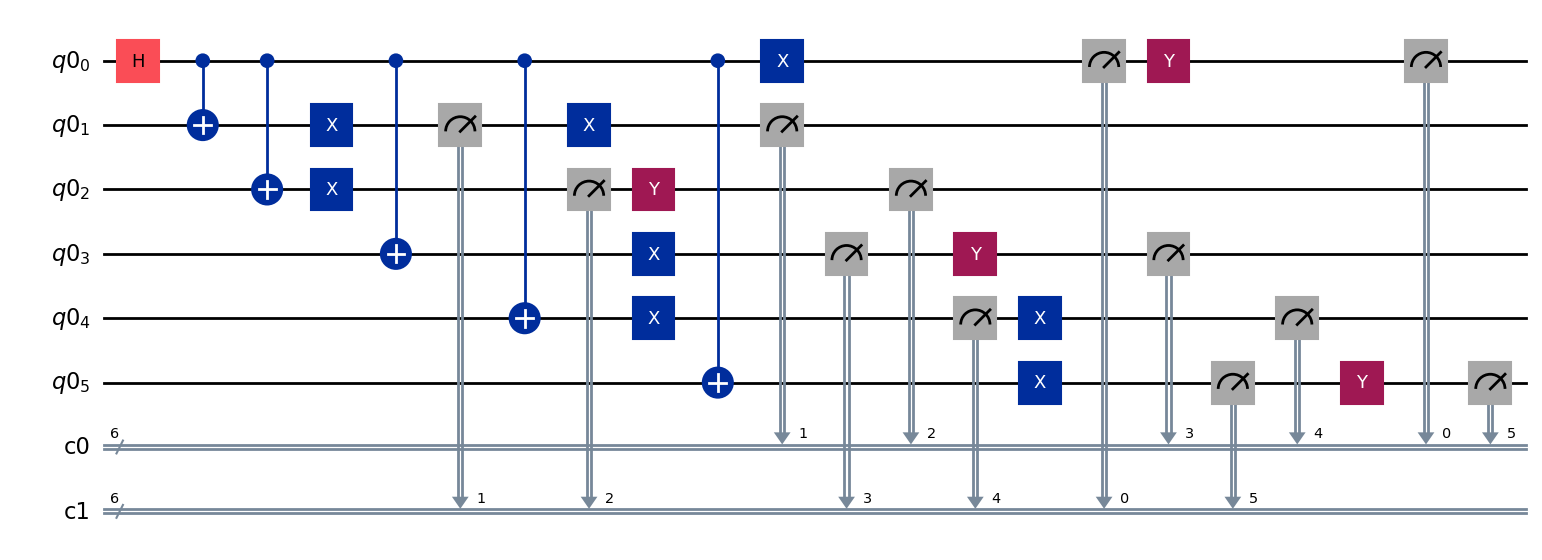

In [24]:
circuits_Eve2[50].draw('mpl')

In [25]:
def simulations(N,backend,circuits_Eve,circuits_Eve2):
    Result_Eve = []
    Result_Eve2 = []


    for k in range(N):
        qc = circuits_Eve[k]
        qc2 = circuits_Eve2[k]

        qct = pm.run(qc)
        qct2 = pm.run(qc2)

        results = sampler.run([qct], shots = 1).result() 
        res = results[0].join_data().get_counts()

        results2 = sampler.run([qct2], shots = 1).result() 
        res2 = results2[0].join_data().get_counts()
    
        Result_Eve.append(res)
        Result_Eve2.append(res2)
        
    return Result_Eve,Result_Eve2
Result_Eve,Result_Eve2 = simulations(N,backend,circuits_Eve,circuits_Eve2)

In [ ]:
Result_Eve = [{'001010011011': 1}, {'110000000011': 1}, {'101011000111': 1}, {'101010101011': 1}, {'011110101001': 1}, {'111001100000': 1}, {'011111001000': 1}, {'001111110110': 1}, {'001101001011': 1}, {'011010110011': 1}, {'000011001110': 1}, {'000101000000': 1}, {'110101010111': 1}, {'001010110010': 1}, {'100110111101': 1}, {'110000011110': 1}, {'110100101101': 1}, {'101101110010': 1}, {'000001110000': 1}, {'111111000101': 1}, {'100010010011': 1}, {'011000100001': 1}, {'100011010110': 1}, {'100010000001': 1}, {'101000101010': 1}, {'000111100010': 1}, {'001001111111': 1}, {'100101110110': 1}, {'100110100101': 1}, {'001100001011': 1}, {'111011001110': 1}, {'010110101001': 1}, {'111100110101': 1}, {'111110010100': 1}, {'110101000110': 1}, {'000001000100': 1}, {'000101001010': 1}, {'101110100101': 1}, {'010111100011': 1}, {'111000101110': 1}, {'111110010100': 1}, {'000111100100': 1}, {'001111101000': 1}, {'111011110110': 1}, {'100101110011': 1}, {'000110110001': 1}, {'001100100001': 1}, {'000110100110': 1}, {'000101010100': 1}, {'011010000011': 1}, {'111001111110': 1}, {'111011000101': 1}, {'000000010011': 1}, {'000101101000': 1}, {'110000110101': 1}, {'011101001110': 1}, {'001111110100': 1}, {'101100011111': 1}, {'101001101100': 1}, {'110100110100': 1}, {'101000011001': 1}, {'011011110100': 1}, {'110001000001': 1}, {'001101011000': 1}, {'010011001100': 1}, {'000111010111': 1}, {'100011101010': 1}, {'000100101001': 1}, {'010111100001': 1}, {'001000001111': 1}, {'111010101010': 1}, {'011011001010': 1}, {'011110101010': 1}, {'101110011000': 1}, {'101101010000': 1}, {'000010001001': 1}, {'110100001011': 1}, {'010001110000': 1}, {'001111001100': 1}, {'100111011011': 1}, {'000010011111': 1}, {'101010001001': 1}, {'111110001001': 1}, {'110100011010': 1}, {'101110011101': 1}, {'011100010101': 1}, {'001000001011': 1}, {'111110011011': 1}, {'111011110001': 1}, {'000101111010': 1}, {'101110000001': 1}, {'011011011000': 1}, {'000111011000': 1}, {'101110000010': 1}, {'000110000111': 1}, {'100101101110': 1}, {'000000010000': 1}, {'000100011101': 1}, {'111111001110': 1}, {'011010100000': 1}, {'001011101000': 1}, {'011001001000': 1}, {'011100010110': 1}, {'110011001111': 1}, {'010110110000': 1}, {'000011011010': 1}, {'101000011111': 1}, {'000001111010': 1}, {'100010110111': 1}, {'100001111010': 1}, {'101111100100': 1}, {'001111010110': 1}, {'010110011001': 1}, {'001111000000': 1}, {'101111001010': 1}, {'000110011010': 1}, {'010000001111': 1}, {'000110101011': 1}, {'110011101000': 1}, {'110000001101': 1}, {'100000101110': 1}, {'100111001111': 1}, {'110100010111': 1}, {'010000001101': 1}, {'010110011101': 1}, {'111101010110': 1}, {'010010100000': 1}, {'101101110100': 1}, {'001010000100': 1}, {'110011011100': 1}, {'100001011100': 1}, {'011000011001': 1}, {'010100000011': 1}, {'011000001001': 1}, {'010010100000': 1}, {'100100111111': 1}, {'101101000001': 1}, {'011001001100': 1}, {'001001010110': 1}, {'111000000001': 1}, {'110001011000': 1}, {'000001000110': 1}, {'111101000110': 1}, {'101101110000': 1}, {'000111111010': 1}, {'000111110010': 1}, {'101011100100': 1}, {'111011011100': 1}, {'010100000101': 1}, {'010100110001': 1}, {'111011100100': 1}, {'110100000001': 1}, {'110101010011': 1}, {'000110001101': 1}, {'110001100000': 1}, {'001001000101': 1}, {'100011010000': 1}, {'101100010101': 1}, {'011101111000': 1}, {'010101011100': 1}, {'110011100010': 1}, {'011000111111': 1}, {'010100000111': 1}, {'110101011010': 1}, {'011111000110': 1}, {'010001000100': 1}, {'000001011001': 1}, {'110010010111': 1}, {'100011110101': 1}, {'011100011000': 1}, {'100011101100': 1}, {'110110101101': 1}, {'100100100011': 1}, {'101110011111': 1}, {'010001000101': 1}, {'010000011001': 1}, {'100100011010': 1}, {'101100110011': 1}, {'010010110111': 1}, {'111100000100': 1}, {'010100101001': 1}, {'110101101111': 1}, {'100111101010': 1}, {'000010000101': 1}, {'101000011101': 1}, {'011111000010': 1}, {'011111011110': 1}, {'111011111101': 1}, {'110110110001': 1}, {'100111111000': 1}, {'010011000011': 1}, {'111111101101': 1}, {'001101111000': 1}, {'011010000001': 1}, {'000001110101': 1}, {'000110100111': 1}, {'101010100001': 1}, {'101100100001': 1}, {'100101111010': 1}, {'000011010111': 1}, {'011111100110': 1}, {'101101100100': 1}, {'011001100010': 1}, {'010000011110': 1}, {'010010010001': 1}, {'011010000001': 1}, {'111101101010': 1}, {'000010101001': 1}, {'000000011001': 1}, {'001000111101': 1}, {'010011011100': 1}, {'110111110010': 1}, {'110010110110': 1}, {'001011000000': 1}, {'000111101011': 1}, {'001111110110': 1}, {'000111100011': 1}, {'110011110010': 1}, {'110110101111': 1}, {'101111001000': 1}, {'010000100010': 1}, {'000101100100': 1}, {'110111111110': 1}, {'101101111100': 1}, {'010110110111': 1}, {'011101110010': 1}, {'011000000000': 1}, {'010011101100': 1}, {'101000011011': 1}, {'111101100100': 1}, {'000111000000': 1}, {'100001001110': 1}, {'000101011101': 1}, {'011001010010': 1}, {'001111110010': 1}, {'110010110111': 1}, {'010001011000': 1}, {'110011100011': 1}, {'101100100010': 1}, {'011101010100': 1}, {'111011111000': 1}, {'011011000100': 1}, {'101000110101': 1}, {'000101011110': 1}, {'001001010110': 1}, {'001001001100': 1}, {'011011110000': 1}, {'010110101011': 1}, {'111011101000': 1}, {'010101100010': 1}, {'010111101011': 1}, {'011100100101': 1}, {'011001000101': 1}, {'110010000100': 1}, {'111000011111': 1}, {'011100000001': 1}, {'001000111001': 1}, {'110110110000': 1}, {'011011111101': 1}, {'000100000111': 1}, {'111100101001': 1}, {'001111001000': 1}, {'000111110010': 1}, {'000010010011': 1}, {'011111110010': 1}, {'010111111110': 1}, {'110111010100': 1}, {'010001101110': 1}, {'111011101100': 1}, {'111010000001': 1}, {'010100101001': 1}, {'000001101101': 1}, {'001100101001': 1}, {'100011111000': 1}, {'111110010101': 1}, {'010010010100': 1}, {'011110110001': 1}, {'011011000001': 1}, {'000000010101': 1}, {'111000011000': 1}, {'111101010110': 1}, {'101101110110': 1}, {'010011001100': 1}, {'110010110111': 1}, {'101000100011': 1}, {'010001001010': 1}, {'110000110011': 1}, {'011101101101': 1}, {'100010001110': 1}, {'000010011101': 1}, {'110000111101': 1}, {'000001100100': 1}, {'000101111010': 1}, {'100001010010': 1}, {'111101010110': 1}, {'111001110011': 1}, {'110000101011': 1}, {'000001000000': 1}, {'110111100000': 1}, {'100000000101': 1}, {'100001100100': 1}, {'001100101101': 1}, {'110101100110': 1}, {'000010100101': 1}, {'100100111111': 1}, {'101111000100': 1}, {'010111010011': 1}, {'101100111111': 1}, {'101000000001': 1}, {'100000010100': 1}, {'110010010001': 1}, {'101111000011': 1}, {'100100000101': 1}, {'010100011001': 1}, {'111010001001': 1}, {'111001110110': 1}, {'010101101110': 1}, {'101111111100': 1}, {'011001110010': 1}, {'110001100100': 1}, {'110101000110': 1}, {'001111000101': 1}, {'000011100100': 1}, {'000000110111': 1}, {'010111001110': 1}, {'111110101100': 1}, {'101100101011': 1}, {'101011000110': 1}, {'010011111101': 1}, {'100110001111': 1}, {'000010111111': 1}, {'010110111111': 1}, {'110110111111': 1}, {'000000011111': 1}, {'011000100001': 1}, {'011101000000': 1}, {'011111000100': 1}, {'111001001000': 1}, {'110101011011': 1}, {'001110111011': 1}, {'110100100111': 1}, {'011011101000': 1}, {'000011000000': 1}, {'010010010001': 1}, {'000110110011': 1}, {'100011001100': 1}, {'101100011011': 1}, {'001111101100': 1}, {'010110111010': 1}, {'111000011011': 1}, {'010110100000': 1}, {'000110010001': 1}, {'100000001111': 1}, {'111000000001': 1}, {'110111010011': 1}, {'101000011111': 1}, {'101011110110': 1}, {'110110111100': 1}, {'010000110111': 1}, {'011011110000': 1}, {'000101001001': 1}, {'000100110110': 1}, {'100110000101': 1}, {'010111101100': 1}, {'110101010110': 1}, {'011111001100': 1}, {'101011001011': 1}, {'110000011111': 1}, {'010110001111': 1}, {'010101001000': 1}, {'101011011111': 1}, {'101011010111': 1}, {'110110010101': 1}, {'000100010101': 1}, {'000010000001': 1}, {'100001010111': 1}, {'110110000101': 1}, {'010101011010': 1}, {'100100001011': 1}, {'101001010011': 1}, {'001001001000': 1}, {'100111110010': 1}, {'110010110011': 1}, {'000100000000': 1}, {'111011100100': 1}, {'001001101110': 1}, {'100011100110': 1}, {'000000100110': 1}, {'110010100101': 1}, {'000000000001': 1}, {'011001111110': 1}, {'000100110001': 1}, {'000010110001': 1}, {'000011101100': 1}, {'010010010010': 1}, {'000001100000': 1}, {'000100000011': 1}, {'100110100011': 1}, {'001001001000': 1}, {'000011111010': 1}, {'010010011110': 1}, {'101101111010': 1}, {'000111011110': 1}, {'100001011100': 1}, {'011101100111': 1}, {'011000110110': 1}, {'100001101111': 1}, {'010110010101': 1}, {'011011111010': 1}, {'011001001100': 1}, {'101101101110': 1}, {'011000100110': 1}, {'001011101010': 1}, {'011000111011': 1}, {'001111011000': 1}, {'010011000100': 1}, {'100101010000': 1}, {'101011111100': 1}, {'111100100110': 1}, {'001000111100': 1}, {'010101011110': 1}, {'101100101101': 1}, {'101110010011': 1}, {'000011000100': 1}, {'110001110010': 1}, {'100110011011': 1}, {'100010100111': 1}, {'101010001001': 1}, {'111110111001': 1}, {'010010110111': 1}, {'001010000001': 1}, {'100101110010': 1}, {'010011110000': 1}, {'000010111001': 1}, {'101100011001': 1}, {'011000100010': 1}, {'000101101100': 1}, {'001100100100': 1}, {'100110010101': 1}, {'111110100101': 1}, {'110001100110': 1}, {'001101000100': 1}, {'110101010010': 1}, {'111011111110': 1}, {'100101111111': 1}, {'011100000011': 1}, {'101111000100': 1}, {'111011001100': 1}, {'110100010111': 1}, {'101010111101': 1}, {'111111000100': 1}, {'010000000011': 1}, {'111011100101': 1}, {'011111101110': 1}, {'100111101011': 1}, {'100111110010': 1}, {'010110100111': 1}, {'011100111110': 1}, {'101000001111': 1}, {'011100111001': 1}, {'110111011010': 1}, {'110000101001': 1}, {'010000111111': 1}, {'010101111110': 1}, {'101000110011': 1}, {'010010000011': 1}, {'110110001001': 1}, {'110101011010': 1}, {'110001001001': 1}, {'010000111111': 1}, {'111100100101': 1}, {'011011010110': 1}, {'001110001011': 1}, {'011000011100': 1}, {'011010111111': 1}, {'010000100010': 1}, {'000011000000': 1}, {'111001100010': 1}, {'001101100110': 1}, {'001010000001': 1}, {'000111101101': 1}, {'110010111011': 1}, {'001101011111': 1}, {'100011011011': 1}, {'110110110111': 1}, {'110001000001': 1}, {'101111001010': 1}, {'010001101100': 1}, {'010000101001': 1}, {'110011101000': 1}, {'110100010001': 1}, {'101100010111': 1}, {'011001100100': 1}, {'010001100110': 1}, {'100100001001': 1}, {'000101011100': 1}, {'111001001010': 1}, {'001111111011': 1}, {'010001001010': 1}, {'110111000000': 1}, {'000110011011': 1}, {'100001011111': 1}, {'111011111000': 1}, {'000101000000': 1}, {'000110110110': 1}, {'101011010010': 1}, {'010000010101': 1}, {'000110100111': 1}, {'101111111110': 1}, {'111001001011': 1}, {'110001000100': 1}, {'110100001101': 1}, {'100000111111': 1}, {'010111111111': 1}, {'110110111010': 1}, {'000101110100': 1}, {'011110110001': 1}, {'100011100111': 1}, {'101000111011': 1}, {'101011110001': 1}, {'011100010101': 1}, {'001101001111': 1}, {'101011111001': 1}, {'111001011001': 1}, {'110111001001': 1}, {'101000110011': 1}, {'110110101110': 1}, {'100111010010': 1}, {'011110011101': 1}, {'011000001111': 1}, {'001100110101': 1}, {'010011001010': 1}, {'000011100100': 1}, {'011000111001': 1}, {'111111100010': 1}, {'101000110100': 1}, {'001000001001': 1}, {'011001100001': 1}, {'001100010011': 1}, {'101110010000': 1}, {'000101101001': 1}, {'110110010100': 1}, {'110111111110': 1}, {'010001101001': 1}, {'110101101101': 1}, {'110010100000': 1}, {'110001110001': 1}, {'010010100010': 1}, {'001001100100': 1}, {'101111001101': 1}, {'010101001100': 1}, {'111100100101': 1}, {'110111010000': 1}, {'001110100011': 1}, {'010111100111': 1}, {'101101001110': 1}, {'000110100100': 1}, {'111111111000': 1}, {'010010011111': 1}, {'111101111000': 1}, {'100011011000': 1}, {'100011110010': 1}, {'100110001101': 1}, {'101110101011': 1}, {'001010011000': 1}, {'011010110011': 1}, {'100000001101': 1}, {'100111110100': 1}, {'111101111110': 1}, {'101101011010': 1}, {'010010111010': 1}, {'110001110110': 1}, {'000110101111': 1}, {'111101000010': 1}, {'110000011101': 1}, {'010101000000': 1}, {'011001001101': 1}, {'110001011001': 1}, {'000110001111': 1}, {'100111000110': 1}, {'010100101101': 1}, {'110001010100': 1}, {'100101011000': 1}, {'100111101010': 1}, {'111110100001': 1}, {'001111100010': 1}, {'100001000110': 1}, {'001001001101': 1}, {'110101001110': 1}, {'001001010010': 1}, {'101111010110': 1}, {'110010100010': 1}, {'011100011110': 1}, {'010010000111': 1}, {'000010001101': 1}, {'011001101111': 1}, {'010011001111': 1}, {'010000110010': 1}, {'100010100101': 1}, {'100110000100': 1}, {'101010011000': 1}, {'110000110111': 1}, {'111010011100': 1}, {'111000001011': 1}, {'111101010010': 1}, {'001011110000': 1}, {'000010011011': 1}, {'100010100011': 1}, {'100010101001': 1}, {'000001100000': 1}, {'000000101111': 1}, {'101011000000': 1}, {'110100000100': 1}, {'010100100000': 1}, {'001011100000': 1}, {'101101011001': 1}, {'101100000101': 1}, {'001011100010': 1}, {'001100100100': 1}, {'100111101011': 1}, {'001000001010': 1}, {'011011100010': 1}, {'111100000000': 1}, {'001010001011': 1}, {'100111111010': 1}, {'011111001110': 1}, {'001010010011': 1}, {'110100011011': 1}, {'101010111001': 1}, {'001001010010': 1}, {'010011011010': 1}, {'010110001101': 1}, {'101101101000': 1}, {'000100101011': 1}, {'000010100111': 1}, {'011001101001': 1}, {'100100111011': 1}, {'001010011011': 1}, {'100001111011': 1}, {'001001111000': 1}, {'011110001111': 1}, {'010010111011': 1}, {'001011101100': 1}, {'010100001101': 1}, {'000101110100': 1}, {'111000101101': 1}, {'000111110010': 1}, {'011110001011': 1}, {'101110000111': 1}, {'001001110111': 1}, {'110111010110': 1}, {'110101101011': 1}, {'011100001011': 1}, {'000000000111': 1}, {'110100001101': 1}, {'110001101000': 1}, {'011010101011': 1}, {'010011100010': 1}, {'111001101111': 1}, {'011011110000': 1}, {'110011001000': 1}, {'011111101010': 1}, {'011000011100': 1}, {'011010001001': 1}, {'101001111110': 1}, {'000101011011': 1}, {'010101110011': 1}, {'001011111101': 1}, {'101100110001': 1}, {'101110001101': 1}, {'011000011101': 1}, {'010111101000': 1}, {'010010010101': 1}, {'011110011011': 1}, {'011100100100': 1}, {'111101111100': 1}, {'100010000101': 1}, {'000010111001': 1}, {'001011111000': 1}, {'011001010100': 1}, {'100010001111': 1}, {'010110001101': 1}, {'001011000000': 1}, {'011110001111': 1}, {'111111010110': 1}, {'110001000111': 1}, {'100101111001': 1}, {'010101000110': 1}, {'001011101111': 1}, {'101110100010': 1}, {'111101111000': 1}, {'111110110010': 1}, {'011101100000': 1}, {'011101101011': 1}, {'110010010111': 1}, {'101010100110': 1}, {'111010100000': 1}, {'000110110110': 1}, {'011001001101': 1}, {'100110100011': 1}, {'100001010100': 1}, {'111001001110': 1}, {'111011001110': 1}, {'000011100001': 1}, {'111100010101': 1}, {'100010110001': 1}, {'110010010000': 1}, {'100000100001': 1}, {'101110111111': 1}, {'001000001111': 1}, {'000001101100': 1}, {'101000010001': 1}, {'111111001000': 1}, {'001011110000': 1}, {'100011110010': 1}, {'100001101000': 1}, {'100101000000': 1}, {'111010101101': 1}, {'101101001101': 1}, {'010100101001': 1}, {'111001111110': 1}, {'110010100001': 1}, {'010110111001': 1}, {'001011110111': 1}, {'111010101001': 1}, {'010111110000': 1}, {'010000101011': 1}, {'001111110100': 1}, {'100011101001': 1}, {'010100010011': 1}, {'101100010111': 1}, {'011110111001': 1}, {'100101001100': 1}, {'010010111100': 1}, {'110110101101': 1}, {'001110110111': 1}, {'101111100010': 1}, {'101110011011': 1}, {'000010100110': 1}, {'110000001111': 1}, {'000110111011': 1}, {'100111100001': 1}, {'010000100111': 1}, {'100010111100': 1}, {'101111101010': 1}, {'101000010010': 1}, {'100110101110': 1}, {'100111111110': 1}, {'010001010100': 1}, {'000000110101': 1}, {'001011010101': 1}, {'101011101100': 1}, {'011001010001': 1}, {'100101110111': 1}, {'010011010100': 1}, {'001011111001': 1}, {'001011000110': 1}, {'000101000100': 1}, {'101001111010': 1}, {'010001010010': 1}, {'110000110111': 1}, {'110000100001': 1}, {'011001011010': 1}, {'011110100011': 1}, {'110111100111': 1}, {'101010010110': 1}, {'000100101111': 1}, {'010011001100': 1}, {'000000011101': 1}, {'100001100100': 1}, {'001111110000': 1}, {'000111011100': 1}, {'001111001000': 1}, {'110111110100': 1}, {'000001001100': 1}, {'110011000000': 1}, {'010000011011': 1}, {'111001010000': 1}, {'000000011011': 1}, {'000111010001': 1}, {'000100101101': 1}, {'010000000110': 1}, {'101100111111': 1}, {'111111000011': 1}, {'010010100001': 1}, {'001101101110': 1}, {'001011010110': 1}, {'110100001010': 1}, {'111011101001': 1}, {'111111000100': 1}, {'100110111111': 1}, {'101100101101': 1}, {'010011110011': 1}, {'101000101001': 1}, {'111101000000': 1}, {'010001100100': 1}, {'110111011100': 1}, {'000011001010': 1}, {'101000010011': 1}, {'111000001011': 1}, {'000001000101': 1}, {'011110001111': 1}, {'111001111010': 1}, {'110101110010': 1}, {'100010101001': 1}, {'010100000101': 1}, {'011001000101': 1}, {'001100110101': 1}, {'000101001110': 1}, {'111000110011': 1}, {'100111011011': 1}, {'111001001010': 1}, {'100101101100': 1}, {'100101110000': 1}, {'110111110100': 1}, {'010111100100': 1}, {'111001110010': 1}, {'101000001101': 1}, {'111111100110': 1}, {'011110010101': 1}, {'101011110100': 1}, {'000110011001': 1}, {'111111101011': 1}, {'110010100111': 1}, {'110101100100': 1}, {'001010101011': 1}, {'010011000101': 1}, {'101111000111': 1}, {'111110100110': 1}, {'000010011010': 1}, {'010101000101': 1}, {'111011001000': 1}, {'011010110111': 1}, {'111000111101': 1}, {'101011101110': 1}, {'110001100000': 1}, {'110010000101': 1}, {'001100100101': 1}, {'011100101000': 1}, {'111101000101': 1}, {'101111110110': 1}, {'110001111100': 1}, {'000100101101': 1}, {'010000110010': 1}, {'010010001010': 1}, {'010010110100': 1}, {'110101101011': 1}, {'101111111000': 1}, {'111011010100': 1}, {'111101000100': 1}, {'000110110001': 1}, {'011010110101': 1}, {'011111110111': 1}, {'101101111110': 1}, {'011001000001': 1}, {'011101110010': 1}, {'101010000100': 1}, {'011111100100': 1}, {'010110000011': 1}, {'011100100011': 1}, {'111001001111': 1}, {'111111110011': 1}, {'011000000110': 1}, {'011111011111': 1}, {'100111100000': 1}, {'110001001100': 1}, {'000100101111': 1}, {'111011100010': 1}, {'110001000110': 1}, {'000100110001': 1}, {'100011011010': 1}, {'100010110101': 1}, {'100010100111': 1}, {'111110101111': 1}, {'011101111000': 1}, {'100010001001': 1}, {'011011101000': 1}, {'110001001001': 1}, {'011101101000': 1}, {'010100110101': 1}, {'000000000111': 1}, {'100110011111': 1}, {'100100001010': 1}, {'011111110100': 1}, {'000010001010': 1}, {'001000000100': 1}, {'000111100110': 1}, {'001000001000': 1}, {'001110010001': 1}, {'011111100110': 1}, {'010000101001': 1}, {'110110101010': 1}, {'110110001001': 1}, {'101110111101': 1}, {'101110011001': 1}, {'001111011110': 1}, {'101111011110': 1}, {'100101100110': 1}, {'110000011110': 1}, {'101111001110': 1}, {'010011110000': 1}, {'100100011011': 1}, {'100111110001': 1}, {'000111001110': 1}, {'111010111011': 1}, {'111010101010': 1}, {'100001001000': 1}, {'011001000010': 1}, {'010001111010': 1}, {'010011110101': 1}, {'010000100110': 1}, {'111101000010': 1}, {'100000111011': 1}, {'110101010000': 1}, {'110100011111': 1}, {'111111100100': 1}, {'100000011101': 1}, {'010001001000': 1}, {'100100111011': 1}, {'100111000011': 1}, {'111001101110': 1}, {'000010011101': 1}, {'011111100110': 1}, {'000101110001': 1}, {'110101111110': 1}, {'011101110010': 1}, {'010111000111': 1}, {'101010011101': 1}, {'001010111110': 1}, {'101100100100': 1}, {'011101001101': 1}, {'001011011001': 1}, {'000111100100': 1}, {'010001111100': 1}, {'101110110111': 1}, {'001110111110': 1}, {'101100010000': 1}, {'111100110111': 1}, {'000010010101': 1}, {'010011010001': 1}, {'011111010010': 1}, {'010100000011': 1}, {'110110010001': 1}, {'001111010100': 1}, {'101011001110': 1}, {'011010111001': 1}, {'011111010000': 1}, {'111110001111': 1}, {'111101111100': 1}, {'010100001101': 1}, {'100110001010': 1}, {'011111001000': 1}, {'000010010100': 1}, {'111100111001': 1}, {'010111111110': 1}, {'110110101011': 1}, {'010111101100': 1}, {'111100011001': 1}, {'111101110110': 1}, {'110010110011': 1}, {'000010001010': 1}, {'010010011111': 1}, {'110110001011': 1}, {'000011000110': 1}, {'110111000000': 1}, {'101110001001': 1}, {'010101010110': 1}, {'001001111101': 1}, {'000010011111': 1}, {'010101010110': 1}, {'100111111110': 1}, {'001011111100': 1}, {'000010011100': 1}, {'000001110010': 1}, {'010111000010': 1}, {'100101000011': 1}, {'000001100101': 1}, {'100110101011': 1}, {'011000100111': 1}, {'010000001111': 1}, {'110101010111': 1}, {'000001111110': 1}, {'100101101011': 1}, {'110000000111': 1}, {'010111101000': 1}, {'101101011110': 1}, {'000110100111': 1}, {'010001001100': 1}, {'101000101111': 1}, {'110001011010': 1}, {'100110010101': 1}, {'100011001100': 1}, {'100110010011': 1}, {'010000010111': 1}, {'011111110000': 1}, {'011101010001': 1}, {'001100010110': 1}, {'000000000111': 1}, {'000011110111': 1}, {'011011000000': 1}, {'011000111100': 1}, {'110001000000': 1}, {'000000101100': 1}, {'110100110100': 1}, {'110010000000': 1}, {'100001110010': 1}, {'101001000000': 1}, {'010101101000': 1}, {'100000000111': 1}, {'000011001100': 1}, {'111100100010': 1}, {'110011001000': 1}, {'011000110100': 1}, {'100011010110': 1}, {'000110110111': 1}, {'001110100010': 1}, {'001010000011': 1}, {'000111010110': 1}, {'011010011010': 1}, {'001000010110': 1}, {'010000110010': 1}, {'101010101111': 1}, {'110000110111': 1}, {'010110011000': 1}, {'001010100010': 1}, {'000000110001': 1}, {'101011000100': 1}, {'110101000010': 1}, {'000010000101': 1}, {'101101100100': 1}, {'100110101100': 1}, {'010100111001': 1}, {'001010101011': 1}, {'001000001101': 1}, {'111100010010': 1}, {'011110100101': 1}, {'011101011011': 1}, {'010011001110': 1}, {'100111111010': 1}, {'001010101001': 1}, {'011100011011': 1}, {'100111100110': 1}, {'110000001101': 1}, {'010110111111': 1}, {'001000101101': 1}, {'110001110010': 1}, {'011001011011': 1}, {'111110101111': 1}, {'000111100001': 1}, {'011001100010': 1}, {'000110111001': 1}, {'001010001101': 1}, {'100101000110': 1}, {'110101111000': 1}, {'001111010111': 1}, {'111101101110': 1}, {'110110100011': 1}, {'111100101010': 1}, {'110011011010': 1}, {'010100101111': 1}, {'111101001101': 1}, {'111010100000': 1}, {'001010101111': 1}, {'110101101010': 1}, {'011100111001': 1}, {'111100111011': 1}, {'101010110001': 1}, {'000011011010': 1}, {'111101001010': 1}, {'011110100111': 1}, {'000010000010': 1}, {'101100010011': 1}, {'111111101000': 1}, {'101111110010': 1}, {'011000100001': 1}, {'001000101111': 1}, {'010001110010': 1}, {'001101100011': 1}, {'111010000001': 1}, {'010101000010': 1}, {'001011011001': 1}, {'111101000110': 1}, {'100001001000': 1}, {'010100010110': 1}, {'001001101111': 1}, {'000011101010': 1}, {'101101001100': 1}, {'111011001110': 1}, {'110110110001': 1}, {'111010110001': 1}, {'000101101110': 1}, {'111110010101': 1}, {'000101101000': 1}, {'110000010111': 1}, {'011101010000': 1}, {'010010101010': 1}, {'000100111001': 1}, {'010001011010': 1}, {'100101000110': 1}, {'001111111000': 1}, {'100110010001': 1}, {'100000010111': 1}, {'011000001100': 1}, {'010100101101': 1}, {'101100100111': 1}, {'000100000111': 1}, {'010011000000': 1}, {'010111110101': 1}, {'100101001100': 1}, {'111100101111': 1}, {'011110110001': 1}, {'010000000010': 1}, {'110011101101': 1}, {'010111110100': 1}, {'011011010000': 1}, {'001011000100': 1}, {'011011011000': 1}, {'010000000001': 1}, {'000000110001': 1}, {'010101110100': 1}, {'100010110111': 1}, {'100100110001': 1}, {'001110011110': 1}, {'010101000011': 1}, {'010110000111': 1}, {'001110110011': 1}, {'010111000110': 1}, {'111000100111': 1}, {'011001100000': 1}, {'111011111011': 1}, {'011100101011': 1}, {'111111000000': 1}, {'111110100010': 1}, {'011011100100': 1}, {'111111010100': 1}, {'101100111001': 1}, {'001011100100': 1}, {'011000011010': 1}, {'010001010100': 1}, {'110011010101': 1}, {'000000001011': 1}, {'101000110101': 1}, {'011001011110': 1}, {'100001010110': 1}, {'000010000001': 1}, {'101001010010': 1}, {'100100011111': 1}, {'110001111110': 1}, {'100011101110': 1}, {'010010100110': 1}, {'101101101110': 1}, {'110011100000': 1}, {'111111100100': 1}, {'100011000100': 1}, {'111101001010': 1}, {'110101100110': 1}, {'111110010111': 1}, {'000011111110': 1}, {'101101010010': 1}, {'100000000011': 1}, {'010110000000': 1}, {'110101000000': 1}, {'111101011111': 1}, {'011001111001': 1}, {'101101110110': 1}, {'000000110111': 1}, {'101000100101': 1}, {'100100110000': 1}, {'110000000111': 1}, {'011100101010': 1}, {'111100110011': 1}, {'011011100001': 1}, {'001110011011': 1}, {'000010000101': 1}, {'100110011010': 1}, {'100110110001': 1}, {'010111110001': 1}, {'101000000110': 1}, {'001101011010': 1}, {'010001111101': 1}, {'100011001111': 1}, {'001110011011': 1}, {'011110101101': 1}, {'100000011100': 1}, {'011000111101': 1}, {'000111101010': 1}, {'001111100110': 1}, {'000001101111': 1}, {'000010111111': 1}, {'111101100100': 1}, {'100110000010': 1}, {'001100010111': 1}, {'100010001001': 1}, {'111101101100': 1}, {'100111111000': 1}, {'011100001100': 1}, {'000110010001': 1}, {'010001111100': 1}, {'000010100001': 1}, {'000010101110': 1}, {'000001000000': 1}, {'011000111100': 1}, {'111101001010': 1}, {'101111000010': 1}, {'010110000001': 1}, {'011110010101': 1}, {'010010100100': 1}, {'110010001000': 1}, {'110110000111': 1}, {'011101101110': 1}, {'001101011000': 1}, {'000100101011': 1}, {'101101010111': 1}, {'010010010111': 1}, {'001001000010': 1}, {'110100100011': 1}, {'101001000010': 1}, {'000110110011': 1}, {'101000000010': 1}, {'101011011100': 1}, {'010101101010': 1}, {'110101100010': 1}, {'100111001011': 1}, {'101001101010': 1}, {'110110110011': 1}, {'100000100111': 1}, {'000000011111': 1}, {'101101110000': 1}, {'100101001011': 1}, {'111001111110': 1}, {'110000010111': 1}, {'000101100010': 1}, {'001100110101': 1}, {'010110011101': 1}, {'111111001011': 1}, {'110111100110': 1}, {'011010011111': 1}, {'011001111010': 1}, {'100010001101': 1}, {'111111100110': 1}, {'000111101000': 1}, {'100110010001': 1}, {'011000001011': 1}, {'001001000010': 1}, {'001001111110': 1}, {'010101101110': 1}, {'001101101010': 1}, {'101110011111': 1}, {'011111010001': 1}, {'101011010000': 1}, {'100110001010': 1}, {'011110010001': 1}, {'000111001010': 1}, {'110100010100': 1}, {'001001010010': 1}, {'001000100111': 1}, {'011000001101': 1}, {'111001010110': 1}, {'001001111100': 1}, {'000010000011': 1}, {'000110001001': 1}, {'011111111010': 1}, {'101111100111': 1}, {'001011001001': 1}, {'111011110011': 1}, {'110110111101': 1}, {'101110110001': 1}, {'000011000000': 1}, {'010001001001': 1}, {'000101001110': 1}, {'010101011100': 1}, {'110101111111': 1}, {'011011000110': 1}, {'111000000000': 1}, {'001110001011': 1}, {'000011011101': 1}, {'010001100101': 1}, {'100101011000': 1}, {'010011010100': 1}, {'010001000011': 1}, {'101100110111': 1}, {'011011101010': 1}, {'000010011110': 1}, {'001011101000': 1}, {'010000111101': 1}, {'011111110000': 1}, {'110011110110': 1}, {'101111010000': 1}, {'110110111011': 1}, {'111111000000': 1}, {'101000000111': 1}, {'110110101001': 1}, {'111111111100': 1}, {'110000000011': 1}, {'111010000111': 1}, {'000011110111': 1}, {'110100011001': 1}, {'010101100100': 1}, {'101000010101': 1}, {'000111101100': 1}, {'000010101001': 1}, {'100001011011': 1}, {'000100001111': 1}, {'000000000101': 1}, {'000011001100': 1}, {'111000101110': 1}, {'100011011111': 1}, {'110000111101': 1}, {'011000110001': 1}, {'010001010100': 1}, {'000100111101': 1}, {'100111000010': 1}, {'001111100100': 1}, {'101110100110': 1}, {'000100010000': 1}, {'010011111010': 1}, {'101011110101': 1}, {'110101011010': 1}, {'000011000101': 1}, {'000111110010': 1}, {'010100101011': 1}, {'100011111100': 1}, {'010001000010': 1}, {'111001110110': 1}, {'110110101111': 1}, {'110011011000': 1}, {'000110111101': 1}, {'111001010000': 1}, {'001100010010': 1}, {'110011101010': 1}, {'010011111000': 1}, {'111111101010': 1}, {'011101111100': 1}, {'000100010001': 1}, {'000111011110': 1}, {'110101110100': 1}, {'100010001011': 1}, {'111111010011': 1}, {'111010100001': 1}, {'000110101011': 1}, {'101011011000': 1}, {'001011110110': 1}, {'111100000011': 1}, {'100110100001': 1}, {'101011010000': 1}, {'101111111101': 1}, {'101011111011': 1}, {'010011001100': 1}, {'011110100001': 1}, {'101000011011': 1}, {'010001100100': 1}, {'010100000010': 1}, {'000010101101': 1}, {'001001010110': 1}, {'111001111100': 1}, {'010101001100': 1}, {'111111001011': 1}, {'110011100100': 1}, {'100000000100': 1}, {'001100001111': 1}, {'010000110000': 1}, {'110110110111': 1}, {'100001101010': 1}, {'110001111100': 1}, {'101001110101': 1}, {'101011100100': 1}, {'011000110100': 1}, {'110100101110': 1}, {'010101101010': 1}, {'000001111010': 1}, {'001101110100': 1}, {'001111010100': 1}, {'110001001110': 1}, {'001010100111': 1}, {'010011101001': 1}, {'000111010000': 1}, {'101110011011': 1}, {'011010111001': 1}, {'100100101110': 1}, {'000001011101': 1}, {'110000111001': 1}, {'010111000010': 1}, {'000010000001': 1}, {'100001000100': 1}, {'001110101011': 1}, {'100000010111': 1}, {'000101011100': 1}, {'110100101001': 1}, {'001000011001': 1}, {'010101000000': 1}, {'100011110001': 1}, {'101000001011': 1}, {'110010110011': 1}, {'011110100001': 1}, {'100000010101': 1}, {'100000111011': 1}, {'100010010001': 1}, {'010011000110': 1}, {'010100000110': 1}, {'100111101110': 1}, {'001110000101': 1}, {'110110100101': 1}, {'010000111011': 1}, {'101100100111': 1}, {'010000111001': 1}, {'010010110111': 1}, {'001011000100': 1}, {'101100010101': 1}, {'000001111100': 1}, {'111001001110': 1}, {'100100100001': 1}, {'110111011000': 1}, {'111000010000': 1}, {'110101111000': 1}, {'101110110111': 1}, {'100010111001': 1}, {'000011011000': 1}, {'110100110011': 1}, {'111100100011': 1}, {'011100001011': 1}, {'011010001010': 1}, {'001010100111': 1}, {'110110000100': 1}, {'011011110100': 1}, {'011001111111': 1}, {'010011100100': 1}, {'001100000111': 1}, {'000100000111': 1}, {'101001010001': 1}, {'110100000010': 1}, {'100111001110': 1}, {'000100001010': 1}, {'100111000001': 1}, {'010010001111': 1}, {'100010000001': 1}, {'111001111000': 1}, {'101011100100': 1}, {'001100010111': 1}, {'011100011011': 1}, {'001010011111': 1}, {'001111001111': 1}, {'101111000011': 1}, {'111000101011': 1}, {'111101000110': 1}, {'001001001100': 1}, {'101101110010': 1}, {'010110010111': 1}, {'101100010010': 1}, {'101011011000': 1}, {'001111001100': 1}, {'001101000010': 1}, {'011010101011': 1}, {'011111000101': 1}, {'101011011000': 1}, {'110100011111': 1}, {'110101001010': 1}, {'101110010111': 1}, {'111010111111': 1}, {'011100010010': 1}, {'000010111011': 1}, {'111100101000': 1}, {'011111001100': 1}, {'001100011001': 1}, {'010110101101': 1}, {'001001101110': 1}, {'000111000110': 1}, {'011000100001': 1}, {'101110100100': 1}, {'100100011001': 1}, {'010010110111': 1}, {'011000100011': 1}, {'111101101000': 1}, {'110001111110': 1}, {'011111110110': 1}, {'100000101111': 1}, {'100001100101': 1}, {'111101010000': 1}, {'101011011100': 1}, {'101001111001': 1}, {'111000011000': 1}, {'110110111111': 1}, {'010101010000': 1}, {'000110111001': 1}, {'000001100101': 1}, {'100101000110': 1}, {'000100001111': 1}, {'110100111011': 1}, {'000110101111': 1}, {'101011011010': 1}, {'101100100001': 1}, {'100010111001': 1}, {'001100001001': 1}, {'001010001101': 1}, {'010110011011': 1}, {'010110011110': 1}, {'010000111100': 1}, {'100110000110': 1}, {'100101001110': 1}, {'000010101101': 1}, {'101101101000': 1}, {'111111010001': 1}, {'000010010001': 1}, {'000000101110': 1}, {'000001110100': 1}, {'110100111101': 1}, {'110100000011': 1}, {'111000111100': 1}, {'001101001110': 1}, {'001011010110': 1}, {'001111000010': 1}, {'011001001110': 1}, {'010011100110': 1}, {'100000100111': 1}, {'010111101101': 1}, {'111000111100': 1}, {'110101101000': 1}, {'101001011100': 1}, {'001110100111': 1}, {'110001101010': 1}, {'100001011001': 1}, {'010101100010': 1}, {'010001111010': 1}, {'001001010100': 1}, {'001110101101': 1}, {'101100100101': 1}, {'001110011111': 1}, {'101011011000': 1}, {'100000010010': 1}, {'111001000010': 1}, {'011100100011': 1}, {'101010001011': 1}, {'111010111001': 1}, {'110110100101': 1}, {'000000100001': 1}, {'100001110110': 1}, {'010100111001': 1}, {'000101100010': 1}, {'101010111011': 1}, {'011010110100': 1}, {'001000001001': 1}, {'100000101111': 1}, {'010010001001': 1}, {'011001111010': 1}, {'010011010010': 1}, {'001001010100': 1}, {'111001111100': 1}, {'010010010101': 1}, {'010100010111': 1}, {'111001110110': 1}, {'100010010100': 1}, {'110101110111': 1}, {'100111100000': 1}, {'111010010011': 1}, {'110011100010': 1}, {'011001100010': 1}, {'011101100100': 1}, {'111011001101': 1}, {'011000101110': 1}, {'100000001011': 1}, {'101101110000': 1}, {'110011110000': 1}, {'001000111010': 1}, {'110100111101': 1}, {'011001100011': 1}, {'010101010110': 1}, {'000010010101': 1}, {'010101010100': 1}, {'110010011001': 1}, {'010110000000': 1}, {'100101100111': 1}, {'100000001101': 1}, {'001110111001': 1}, {'111001000100': 1}, {'100011110100': 1}, {'000001000010': 1}, {'100000001010': 1}, {'111000011111': 1}, {'111111111100': 1}, {'100110000000': 1}, {'000110111011': 1}, {'010000111000': 1}, {'111010011111': 1}, {'000100111110': 1}, {'101110111101': 1}, {'000001101100': 1}, {'101010110111': 1}, {'110111101010': 1}, {'110010101111': 1}, {'101000101100': 1}, {'001010100101': 1}, {'101101111100': 1}, {'110010101111': 1}, {'101111111000': 1}, {'101001001110': 1}, {'001001110000': 1}, {'001011000010': 1}, {'111110110001': 1}, {'011010011111': 1}, {'011110111010': 1}, {'010111100100': 1}, {'111010100101': 1}, {'111110011001': 1}, {'111100001001': 1}, {'111011001000': 1}, {'110101010111': 1}, {'001100010101': 1}, {'000010110001': 1}, {'000100011011': 1}, {'101011000000': 1}, {'100100111000': 1}, {'100011011010': 1}, {'011011010110': 1}, {'010101010110': 1}, {'001001010000': 1}, {'110010011001': 1}, {'100001100000': 1}, {'000000000001': 1}, {'101000011111': 1}, {'110111001100': 1}, {'011010000000': 1}, {'111111001010': 1}, {'100011110110': 1}, {'001110001101': 1}, {'010001010010': 1}, {'000010101010': 1}, {'111110100111': 1}, {'001011100100': 1}, {'111100110111': 1}, {'001010011011': 1}, {'001110011011': 1}, {'100001011000': 1}, {'011001010010': 1}, {'111000111010': 1}, {'100111000101': 1}, {'011100011010': 1}, {'001010100111': 1}, {'111001111011': 1}, {'000011110101': 1}, {'101001011110': 1}, {'011010110110': 1}, {'011110001001': 1}, {'101111110010': 1}, {'000110110110': 1}, {'000010110111': 1}, {'010000000001': 1}, {'000000111111': 1}, {'000011101000': 1}, {'001001000010': 1}, {'111111100000': 1}, {'001011101101': 1}, {'101011000110': 1}, {'111001101011': 1}, {'010001111111': 1}, {'100100000101': 1}, {'000000110111': 1}, {'000100110011': 1}, {'001111100100': 1}, {'010011000110': 1}, {'011001000100': 1}, {'111110111000': 1}, {'110001011010': 1}, {'000000011001': 1}, {'101011101010': 1}, {'011101110000': 1}, {'010110100001': 1}, {'101001010000': 1}, {'110011100000': 1}, {'011111111010': 1}, {'100011111000': 1}, {'000011000110': 1}, {'010110110011': 1}, {'000110011011': 1}, {'101010010011': 1}, {'101100110011': 1}, {'011001111100': 1}, {'111110001011': 1}, {'011110100000': 1}, {'001000101010': 1}, {'010111111001': 1}, {'101010010001': 1}, {'000011100011': 1}, {'011001000100': 1}, {'000001110110': 1}, {'001011001011': 1}, {'100111111000': 1}, {'110110000101': 1}, {'100110010101': 1}, {'010100010001': 1}, {'100000010111': 1}, {'001111101000': 1}, {'110000010111': 1}, {'000110000011': 1}, {'110110101001': 1}, {'001010001011': 1}, {'000010101011': 1}, {'101010110100': 1}, {'001110100001': 1}, {'111111010010': 1}, {'100011100010': 1}, {'010000101010': 1}, {'001010100001': 1}, {'101010101011': 1}, {'000110100111': 1}, {'110101011001': 1}, {'001010010011': 1}, {'101000001111': 1}, {'001101010001': 1}, {'111001010110': 1}, {'001100110000': 1}, {'100000111011': 1}, {'101101110100': 1}, {'011110111001': 1}, {'011111010011': 1}, {'001011011100': 1}, {'111101011000': 1}, {'000110111001': 1}, {'111011010010': 1}, {'000010011101': 1}, {'110100010001': 1}, {'011000001011': 1}, {'011101010110': 1}, {'010101000001': 1}, {'100000111101': 1}, {'111000110011': 1}, {'101010000101': 1}, {'001100010111': 1}, {'001000110111': 1}, {'000101010011': 1}, {'011100011100': 1}, {'111010101101': 1}, {'001010000001': 1}, {'000100100111': 1}, {'000011011110': 1}, {'010010000011': 1}, {'111110101011': 1}, {'111010001110': 1}, {'001011001011': 1}, {'010011100110': 1}, {'101011010001': 1}, {'110111000000': 1}, {'000101111000': 1}, {'100001110110': 1}, {'001010110100': 1}, {'101011111010': 1}, {'001000111011': 1}, {'011010100011': 1}, {'010011101010': 1}, {'010110000000': 1}, {'000101011000': 1}, {'001110011101': 1}, {'101101000000': 1}, {'110110011111': 1}, {'100101111110': 1}, {'110010010001': 1}, {'001111100000': 1}, {'101111111110': 1}, {'111101001001': 1}, {'110111100000': 1}, {'111101000000': 1}, {'110111111010': 1}, {'101111111010': 1}, {'010011100100': 1}, {'001011001010': 1}, {'000001111000': 1}, {'101011001010': 1}, {'001001011110': 1}, {'010110100111': 1}, {'011100010001': 1}, {'110100101001': 1}, {'110111010000': 1}, {'010011111010': 1}, {'101011001010': 1}, {'110110101001': 1}, {'011001010010': 1}, {'110011011010': 1}, {'000110011101': 1}, {'100001100100': 1}, {'001001110110': 1}, {'000101111100': 1}, {'101110110100': 1}, {'100010100100': 1}, {'001011001111': 1}, {'101011100110': 1}, {'101010001001': 1}, {'000110111010': 1}, {'001100011111': 1}, {'100100011001': 1}, {'110011000110': 1}, {'010011011000': 1}, {'000111111000': 1}, {'111111101101': 1}, {'011000011011': 1}, {'101100010011': 1}, {'110101101100': 1}, {'110000010101': 1}, {'000000110111': 1}, {'010110100111': 1}, {'101000110011': 1}, {'101111000100': 1}, {'010100001001': 1}, {'111101100101': 1}, {'000110011110': 1}, {'010001111011': 1}, {'000001111010': 1}, {'100001101000': 1}, {'011110111110': 1}, {'110001110100': 1}, {'100011010110': 1}, {'101111101000': 1}, {'100010000101': 1}, {'101101111111': 1}, {'011111100010': 1}, {'011111101110': 1}, {'001100101000': 1}, {'110010000101': 1}, {'000001001010': 1}, {'000110011011': 1}, {'100110101001': 1}, {'010111010100': 1}, {'100001100011': 1}, {'000001000110': 1}, {'001010010111': 1}, {'010001011101': 1}, {'111001001010': 1}, {'110110010111': 1}, {'100010000101': 1}, {'011010001110': 1}, {'100001101100': 1}, {'011000010100': 1}, {'111011100000': 1}, {'101101011110': 1}, {'111011101010': 1}, {'110110000011': 1}, {'100011111010': 1}, {'110010110001': 1}, {'000011000101': 1}, {'011100011111': 1}, {'110010001101': 1}, {'101110101111': 1}, {'110111000100': 1}, {'100101000000': 1}, {'111001111010': 1}, {'001011101100': 1}, {'001110100011': 1}, {'011010001111': 1}, {'000001001000': 1}, {'010101111010': 1}, {'111100101111': 1}, {'110110110011': 1}, {'001111011001': 1}, {'010100001011': 1}, {'001100001110': 1}, {'111111101101': 1}, {'111010000100': 1}, {'001110101011': 1}, {'110100000011': 1}, {'011110011011': 1}, {'110100110000': 1}, {'101101000101': 1}, {'101111001101': 1}, {'000101001010': 1}, {'110010001011': 1}, {'011110010001': 1}, {'100001010000': 1}, {'000100011111': 1}, {'011001111010': 1}, {'010010011010': 1}, {'100001001101': 1}, {'010001101100': 1}, {'000101101100': 1}, {'100110011110': 1}, {'010100011111': 1}, {'000000100000': 1}, {'100101001010': 1}, {'000101111010': 1}, {'000000111011': 1}, {'100101101000': 1}, {'111000101100': 1}, {'111000000111': 1}, {'100110001001': 1}, {'011000111010': 1}, {'101000100011': 1}, {'001000111001': 1}, {'110101110101': 1}, {'000111000001': 1}, {'010111110011': 1}, {'000101101011': 1}, {'001100010011': 1}, {'111100100100': 1}, {'000011100110': 1}, {'011010100011': 1}, {'100011110100': 1}, {'110011100010': 1}, {'001101000010': 1}, {'101000100011': 1}, {'000101011010': 1}, {'011110000101': 1}, {'000001100100': 1}, {'010001011010': 1}, {'100011000101': 1}, {'001011010000': 1}, {'101111110100': 1}, {'101010000011': 1}, {'000001001010': 1}, {'011101000101': 1}, {'011011111110': 1}, {'110001010110': 1}, {'110111011001': 1}, {'100001001010': 1}, {'111010001001': 1}, {'100000011110': 1}, {'111111111110': 1}, {'001011011011': 1}, {'011101111100': 1}, {'000011010111': 1}, {'010000010011': 1}, {'110011010110': 1}, {'111011111101': 1}, {'001000001011': 1}, {'011100100110': 1}, {'010000100101': 1}, {'101101001000': 1}, {'001000111111': 1}, {'011011011010': 1}, {'111011001010': 1}, {'001111001100': 1}, {'100111010100': 1}, {'001100110011': 1}, {'010100101101': 1}, {'011001101010': 1}, {'110000111111': 1}, {'001001000101': 1}, {'000100000011': 1}, {'000001010010': 1}, {'011001010110': 1}, {'011001101000': 1}, {'001110011101': 1}, {'101101111100': 1}, {'110101111010': 1}, {'110110010001': 1}, {'110110000110': 1}, {'101110101010': 1}, {'100000110001': 1}, {'111101000111': 1}, {'100010000000': 1}, {'111111010010': 1}, {'001011111001': 1}, {'111001001110': 1}, {'010001010100': 1}, {'111101001101': 1}, {'101110110001': 1}, {'010101001100': 1}, {'110001001000': 1}, {'001110001001': 1}, {'000011111110': 1}, {'010001011010': 1}, {'000000101001': 1}, {'010000101011': 1}, {'010101111110': 1}, {'000110001001': 1}, {'111111110010': 1}, {'100111001100': 1}, {'001101100101': 1}, {'000000111011': 1}, {'101100011111': 1}, {'000111110110': 1}, {'111101100000': 1}, {'111000111001': 1}, {'101011010110': 1}, {'001001101000': 1}, {'100001111011': 1}, {'100011101010': 1}, {'111100001001': 1}, {'011010100101': 1}, {'111111100100': 1}, {'101111110000': 1}, {'011110010011': 1}, {'100010111111': 1}, {'011001011000': 1}, {'001110100011': 1}, {'010111110011': 1}, {'000001010010': 1}, {'111101110001': 1}, {'010000100101': 1}, {'111111110000': 1}, {'111110000101': 1}, {'110101000111': 1}, {'000111100100': 1}, {'110011001111': 1}, {'100001111000': 1}, {'011011010101': 1}, {'110010111111': 1}, {'010011001100': 1}, {'101001001111': 1}, {'001110110101': 1}, {'111001000110': 1}, {'111100001001': 1}, {'100111010000': 1}, {'100001101100': 1}, {'110100000001': 1}]
Result_Eve2 = [{'111111000101': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000110111': 1}, {'000001111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000011111': 1}, {'000000111110': 1}, {'111101000010': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111011': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'010000100110': 1}, {'010000101111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111011000001': 1}, {'111111000000': 1}, {'000000011111': 1}, {'111110000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111011': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111011000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111011000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111011': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000011111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'010000101110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111101': 1}, {'101111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000110111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'101111011000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111010': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000110111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111100': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000101111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'001110100001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'110111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111011': 1}, {'000000111011': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'011111100001': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111101': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111011000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'110001001110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111011': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111011': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'101101000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000100': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000110111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111110000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000110111': 1}, {'111011000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'100000011011': 1}, {'000010111101': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111011': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'001000110111': 1}, {'111111000000': 1}, {'000001111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111011': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'110111000001': 1}, {'000001111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111010': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000101': 1}, {'000000111111': 1}, {'000000011111': 1}, {'111111000000': 1}, {'011111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111101000000': 1}, {'111111000101': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'110001001111': 1}, {'000000111111': 1}, {'001110110001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000110110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111110000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111110000001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111101': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'011110100001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000101': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'110111000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111110000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000100': 1}, {'111111000001': 1}, {'000000110111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000010111101': 1}, {'000000110110': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111011000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111011': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111101000010': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000011111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000011110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'010000101111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'100000011110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'101111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111011000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111001000110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'011111100100': 1}, {'011111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111100000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'110001001110': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000100': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'001000110111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111011': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000011111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000100': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111101000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'110111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111011000001': 1}, {'000000111010': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'101111010001': 1}, {'111111001000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'110001001110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000011111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111101000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'001110110001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000010111111': 1}, {'011111100101': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000001111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'011111100000': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111010': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111011000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111101000010': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000011110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'101111011001': 1}, {'111111000000': 1}, {'011111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'011111100000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000011111': 1}, {'110111001000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111101000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111001101': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'011111100000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'100000011111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'110111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111011000000': 1}, {'000000111111': 1}, {'110111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111100001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000101110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000010111100': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111001000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111101': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111101000001': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111011000100': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'110111001000': 1}, {'111111000000': 1}, {'111011000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111100': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111011000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111011': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111110000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111101000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111011': 1}, {'010000100111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111011000000': 1}, {'110001001110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000010111101': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000110111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000100': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'101111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'011111000000': 1}, {'011111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000011111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000100': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'011111100000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000110111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111010': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000100': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111011000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111110000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111110000001': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000011111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111101000010': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111101000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000110111001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'101111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111101000010': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111011': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'011110100001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'010000101111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'101111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000010111100': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111011': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'101111011001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000011111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111011': 1}, {'000000101111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111011': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'100000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'110111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'100000011111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'110111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111101000100': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'110111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111101001000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'011111000001': 1}, {'000000111111': 1}, {'000001111110': 1}, {'000000111111': 1}, {'111011000000': 1}, {'000000111111': 1}, {'000000111110': 1}, {'001100110011': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111110': 1}, {'110111000000': 1}, {'000000111110': 1}, {'111111000001': 1}, {'000000111110': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111011000000': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'111111000000': 1}, {'000000111110': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000010111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000011': 1}, {'000000111111': 1}, {'111111000001': 1}, {'000000111111': 1}, {'000000111110': 1}, {'000000111111': 1}, {'000000111111': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'111111000000': 1}, {'000000111111': 1}]


In [28]:
def Legitimate_parties_secret_key_with_Eve(nq,N,Result_Eve):
    keyss_Legitimate_parties = np.array([[0]*N]*nq)
    for k in range(N):
        key = list(Result_Eve[k].keys())
        for j in range(nq):
            if key[0][nq+j] == '1':
                keyss_Legitimate_parties[j,k] = '1'
            elif key[0][nq+j] == '0':
                keyss_Legitimate_parties[j,k] = '0'
    
    Res = []
    L = [] #contains the set of measurement basis for key generation at potision determined by k_list
    k_list = [] #This is the list giving the position of all measurement basis where the first user
    # select either X or Y.
    for k in range(N):
        if basis_choices[0][k] == 'X':
            l = ['X']
            for j in range(1,nq):
                l.append(basis_choices[j][k])
            L.append(l)
            k_list.append(k)
        elif basis_choices[0][k] == 'Y':
            l = ['Y']
            for j in range(1,nq):
                l.append(basis_choices[j][k])            
            L.append(l)
            k_list.append(k)

    Y_counter = []#This contains the number of Y basis in each set of bases in L
    for k in range(len(L)):
        compt = 0
        for j in range(len(L[0])):
            if L[k][j] == 'Y':
                compt += 1
        Y_counter.append(compt)
    
    Keys_Legitimate_parties = [] #this contains the set of key bit of each user
    for k in range(nq):
        q = keyss_Legitimate_parties[k]
        A = []
        for j in range(len(Y_counter)):
            if Y_counter[j]%2 == 0:# because when the is an odd number of Y basis selected the user
                                    # are most likely to get the same output results. 
                A.append(str(q[k_list[j]]))  
        Keys_Legitimate_parties.append(A)
    generated_keys_Legitimate_parties = []
    for k in range(len(Keys_Legitimate_parties)):
        x = ''
        for j in Keys_Legitimate_parties[k]:
            x += j
        generated_keys_Legitimate_parties.append(x)

    
    return generated_keys_Legitimate_parties
generated_keys_Legitimate_parties = Legitimate_parties_secret_key_with_Eve(nq,N,Result_Eve2)
generated_keys_Legitimate_parties

['110010100101010000101110100110000110100111100001011010000010111010001011101110011111101011100110111000000001011010101010011011111011011010001100001011110101010110010001001010100000010110011000000110010101001000111111100111111110000000011111110001000100010000011011110011100001111101101001010110011101111000100001101011010000001100001010010110110110000011111000011111101100000110000011011000011001010011011000111011000100010001001100100010100110011011101101000011001010011010101100110000001011100011100011000101000011110111011111100111110000110000',
 '110010100111010000101110100110000110100111100001011010000010100010001011101110011111101011100110111000000001011010101010011011111011011010001100001011110101010110010001001010100000010110011000000110010101000000111111101111111110000000011111110001000100010000011011110011000001111101101001010110011101111000100001111011010000001100001010010110110110000011111000011111101100000110000011011000011001010011011000111011000100010001001100110010100110011

In [29]:
Keylength = [len(generated_keys_Legitimate_parties[k]) 
             for k in range(len(generated_keys_Legitimate_parties))]
Keylength

[546, 546, 546, 546, 546, 546]

In [30]:
#To compute the bit error rate I compare the bit of the first legitimate user
# to those of the remaining. It works as follows: I take the kth bit of the first user, compare
#compare with the kth bit of others, the mismatching is incremented by 1 when at least one bit
#differs.
def Legitimate_parties_QBER_with_eve(Keylength,keys):
    Numb_mismatching_bits = 0 
    x = keys[0]
    if Keylength[0] == 0:
        print('Unsucessful')
    else:
        for j in range(Keylength[0]):
            for k in range(1,nq):
                if x[j] != keys[k][j]:
                    Numb_mismatching_bits +=1
                    break
        QBER = Numb_mismatching_bits/Keylength[0]*100
    return QBER
        
QBER_with_Eve = Legitimate_parties_QBER_with_eve(Keylength,generated_keys_Legitimate_parties)
print('QBER = ', QBER_with_Eve,'%')

QBER =  5.86080586080586 %


In [31]:
def Eve_extracted_keys(nq,N,Result_Eve):
    keyss_Eve = np.array([[0]*N]*nq)
    for k in range(N):
        key = list(Result_Eve[k].keys())
        for j in range(nq):
            if key[0][j] == '1':
                keyss_Eve[j,k] = '1'
            elif key[0][j] == '0':
                keyss_Eve[j,k] = '0'

    
    L = [] #contains the set of measurement basis for key generation at potision determined by k_list
    k_list = [] #This is the list giving the position of all measurement basis where the first user
    # select either X or Y.
    for k in range(N):
        if basis_choices[0][k] == 'X':
            l = ['X']
            for j in range(1,nq):
                l.append(basis_choices[j][k])
            L.append(l)
            k_list.append(k)
        elif basis_choices[0][k] == 'Y':
            l = ['Y']
            for j in range(1,nq):
                l.append(basis_choices[j][k])            
            L.append(l)
            k_list.append(k)

    Y_counter = []#This contains the number of Y basis in each set of bases in L
    for k in range(len(L)):
        compt = 0
        for j in range(len(L[0])):
            if L[k][j] == 'Y':
                compt += 1
        Y_counter.append(compt)
    
    #Here I am extracting the bit where the measurement basis correspond to the 
    Keys_Eve = [] #this contains the set of key bit of each user
    for k in range(nq):
        q = keyss_Eve[k]
        A = []
        for j in range(len(Y_counter)):
            if Y_counter[j]%2 == 0:# because when the is an odd number of Y basis selected the user
                                    # are most likely to get the same output results. 
                A.append(str(q[k_list[j]]))  
        Keys_Eve.append(A)
    generated_keys_Eve = []
    for k in range(len(Keys_Eve)):
        x = ''
        for j in Keys_Eve[k]:
            x += j
        generated_keys_Eve.append(x)

    return generated_keys_Eve
generated_keys_Eve = Eve_extracted_keys(nq,N,Result_Eve)
print(generated_keys_Eve)

['000110011000101010010100010000000100110101000110001011011000010000100001000101110010010000101111101001000010101011111000010111001001111100100001011111011000110010001000000000000001011111010010011001000100000110001101011101110011010001000111110011011110001101011010100001111011001111100101110110000000101101011111111001000000110101010110010011000010010111001011111100101100001011001001011001001000110000001000000011011001100010111101001010110000100010001111001111010010010111000101101011110001011111110001000011100101000111000011100011001101100111', '1000010011101010110000100010101000101011010110111100001110110010011100111011001111100000111010000111010000000100001011111101011100110010110101011001000010100001000000010101111111111101001111011010011101010011110011111011011111111011001010000011011010101111111111100011110000100111111111001100001001111110100010101100000011000111101000101100000000100010100000111111000111011011000101011000001010101110001010011000001011100110100001110000101000010001

In [32]:
def Percentage_info_learnt_by_Eve(generated_keys_Eve):
    Percentage_Eve_mismatching_bits = [] 
    
    for k in range(len(generated_keys_Eve)):
        Numb_mismatching_bits =0
        x = generated_keys_Eve[k]
        Eve_Keylength = len(generated_keys_Eve[k])
        if Eve_Keylength == 0:
            Numb_Eve_mismatching_bits.append('Unsucessful')
        else:
            for j in range(Eve_Keylength):
                if x[j] != generated_keys[k][j]:
                    Numb_mismatching_bits +=1
                    # break
            QBER = Numb_mismatching_bits/Keylength[0]*100
            Percentage_Eve_mismatching_bits.append(QBER)
    return Percentage_Eve_mismatching_bits

Percentage_Eve_mismatching_bits  = Percentage_info_learnt_by_Eve(generated_keys_Eve)
print('Percentage of Eve mismatching bits = ', Percentage_Eve_mismatching_bits)

Percentage of Eve mismatching bits =  [51.83150183150184, 53.47985347985348, 46.336996336996336, 49.08424908424908, 53.2967032967033, 49.08424908424908]


In [34]:
correlation2 = Corrrelation(basis_choices,Result_Eve2)
print('The Sveltchiny correlation is with eavesdropper interference is',np.round(correlation2,3))
      # 'compared to the theoretical values',np.round(correlation2[1],3))


The Sveltchiny correlation is with eavesdropper interference is 1.298
